# Emergent Subspaces Observatory

This notebook is a small research instrument for observing how dominant subspaces form, move, split, and stabilize during neural network training.

The central idea is simple:

> A training run is not only a loss curve. It is also a trajectory of weight matrices, gradients, activations, and dominant subspaces.

This notebook trains a tiny Qwen-style language model on WikiText-2 with a simple word-level tokenizer and compares two optimizers:

- **AdamW**
- **Muon-style orthogonalized momentum optimizer**

During training, the notebook records the evolution of selected weight matrices and visualizes:

- top-k singular subspaces
- principal-angle drift
- anchor alignment to final subspaces
- subspace emergence scores
- stabilization times
- spectral gaps
- stable rank
- weight velocity and acceleration
- optimizer-specific phase diagrams
- automatically detected subspace events
- clustering of training states into interpretable regimes

The purpose is educational and exploratory, not state-of-the-art language modeling.

## Why subspaces?

A neural network weight matrix can be decomposed as:

\[
W_t = U_t \Sigma_t V_t^\top
\]

The top singular vectors define dominant input and output directions. Instead of looking only at individual weights, we track the **top-k subspace**:

\[
V_k^{(t)}
\]

This lets us ask:

- When does a dominant subspace first appear?
- Does it stabilize early or late?
- Does AdamW create sharper, lower-dimensional subspaces than Muon?
- Do different optimizers reach similar loss through different internal geometries?
- Are there phase transitions in training that are invisible in the loss curve?

For readers who do not know the linear algebra, think of a subspace as a learned "directional group" or "representational channel" inside the matrix. The notebook visualizes these groups as timelines, heatmaps, and clusters.

## References

The notebook is inspired by several research lines:

- Amari, S. (1998). *Natural Gradient Works Efficiently in Learning.* Neural Computation.
- Martens, J. and Grosse, R. (2015). *Optimizing Neural Networks with Kronecker-factored Approximate Curvature.* ICML.
- Raghu et al. (2017). *SVCCA: Singular Vector Canonical Correlation Analysis for Deep Learning Dynamics and Interpretability.* NeurIPS.
- Kornblith et al. (2019). *Similarity of Neural Network Representations Revisited.* ICML.
- Martin and Mahoney (2018-2021). Heavy-tailed and random-matrix analyses of deep neural network weight matrices.
- Gidaris et al. / Liu et al. style orthogonalized-gradient optimizers are related in spirit to Muon-like updates.

This notebook is not a faithful reproduction of any single paper. It is a compact laboratory for experimenting with the ideas.

## Methodological revision notes

This version incorporates several fixes from review:

- Larger default model and longer default run for clearer spectral structure.
- AdamW uses standard \(\beta_2=0.999\).
- Muon learning rate is reduced to a comparable scale.
- Both optimizers use warmup plus cosine decay.
- `adamw_high_lr` is added as a control run.
- Attention Q/K/V slices are included in the tracked matrices.
- Subspace drift now uses principal-angle Grassmann distance.
- Velocity and acceleration are normalized by current \(\|W_t\|_F\).
- Final-anchor alignment is kept, but rolling alignment is added to reduce teleological bias.
- Clustering prefers DBSCAN/UMAP when available and falls back to silhouette-selected KMeans/PCA.

In [1]:
# Optional installation cell.
# Uncomment if running in a fresh environment.
#
# !pip install torch datasets matplotlib pandas numpy tqdm scikit-learn scipy
# Optional, for nonlinear embedding:
# !pip install umap-learn

import math
import random
import time
import re
from dataclasses import dataclass
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

try:
    from datasets import load_dataset
    HAS_DATASETS = True
except Exception:
    HAS_DATASETS = False

try:
    from sklearn.cluster import KMeans, DBSCAN
    from sklearn.decomposition import PCA, FastICA
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import silhouette_score
    HAS_SKLEARN = True
except Exception:
    HAS_SKLEARN = False

try:
    from scipy.optimize import linear_sum_assignment
    HAS_SCIPY = True
except Exception:
    HAS_SCIPY = False

try:
    from umap import UMAP
    HAS_UMAP = True
except Exception:
    HAS_UMAP = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
print("sklearn available:", HAS_SKLEARN)
print("scipy available:", HAS_SCIPY)
print("optional UMAP available:", HAS_UMAP)

Device: cuda
Optional UMAP available: True


In [2]:
@dataclass
class Config:
    # Data
    vocab_size: int = 30000
    seq_len: int = 64
    train_tokens_limit: object = None
    val_tokens_limit: object = None

    # Model
    d_model: int = 256
    n_layers: int = 4
    n_heads: int = 4
    d_ff: int = 768
    dropout: float = 0.1

    # Training
    batch_size: int = 32
    max_steps: int = 2000
    eval_interval: int = 100
    diag_interval: int = 100
    lr: float = 3e-4
    adamw_high_lr: float = 1e-3
    weight_decay: float = 0.1
    grad_clip: float = 1.0
    warmup_steps: int = 100
    adamw_beta2: float = 0.999
    eval_train_batches: int = 10
    eval_val_batches: int = 30

    # Muon-like optimizer
    # Comparable scale to AdamW instead of the earlier very aggressive 50x LR.
    muon_lr: float = 1e-3
    muon_momentum: float = 0.95
    muon_ns_steps: int = 5

    # Diagnostics
    # FFN down projections plus attention matrices. The model uses a fused qkv
    # projection, so q/k/v slices are extracted in get_named_matrix().
    target_matrices: tuple = (
        "blocks.0.mlp.down.weight",
        "blocks.0.attn.q_proj.weight",
        "blocks.0.attn.k_proj.weight",
        "blocks.0.attn.v_proj.weight",
        "blocks.1.mlp.down.weight",
        "blocks.2.mlp.down.weight",
        "blocks.2.attn.q_proj.weight",
        "blocks.2.attn.v_proj.weight",
        "blocks.3.mlp.down.weight",
    )
    top_k_values: tuple = (1, 2, 4, 8, 16)
    svd_rank_for_plots: int = 48
    stabilization_epsilon: float = 0.03
    stabilization_patience: int = 4
    rolling_anchor_lag_steps: int = 300

    # ICA / component observatory
    # These settings keep the Tiny Qwen model unchanged and only analyze FFN activations.
    ica_enabled: bool = True
    ica_eval_batch_size: int = 32
    ica_eval_max_sequences: int = 64
    ica_eval_max_unk_ratio_per_sequence: float = 0.05
    ica_variance_threshold: float = 0.90
    ica_max_components: int = 64
    ica_min_components: int = 4
    ica_whiten: str = "unit-variance"
    ica_algorithm: str = "parallel"
    ica_fun: str = "logcosh"
    ica_max_iter: int = 5000
    ica_tol: float = 1e-5
    ica_random_state: int = 42
    ica_match_threshold: float = 0.65
    ica_bind_threshold: float = 0.35


    # Experiment modes
    optimizers_to_run: tuple = ("adamw", "adamw_high_lr", "muon")

    # Reproducibility
    seed: int = 42

CONFIG = Config()
CONFIG

Config(vocab_size=12000, seq_len=64, train_tokens_limit=500000, val_tokens_limit=80000, d_model=256, n_layers=4, n_heads=4, d_ff=768, dropout=0.1, batch_size=32, max_steps=2000, eval_interval=100, diag_interval=100, lr=0.0003, adamw_high_lr=0.001, weight_decay=0.1, grad_clip=1.0, warmup_steps=100, adamw_beta2=0.999, eval_train_batches=10, eval_val_batches=30, muon_lr=0.001, muon_momentum=0.95, muon_ns_steps=5, target_matrices=('blocks.0.mlp.down.weight', 'blocks.0.attn.q_proj.weight', 'blocks.0.attn.k_proj.weight', 'blocks.0.attn.v_proj.weight', 'blocks.1.mlp.down.weight', 'blocks.2.mlp.down.weight', 'blocks.2.attn.q_proj.weight', 'blocks.2.attn.v_proj.weight', 'blocks.3.mlp.down.weight'), top_k_values=(1, 2, 4, 8, 16), svd_rank_for_plots=48, stabilization_epsilon=0.03, stabilization_patience=4, rolling_anchor_lag_steps=300, optimizers_to_run=('adamw', 'adamw_high_lr', 'muon'), seed=42)

In [3]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(CONFIG.seed)

## Data-pipeline fix

This version keeps the original word-level tokenizer, but changes the data setup to avoid an artificial validation-loss plateau:

- use the full WikiText-2 train/validation token streams instead of truncating them early;
- increase the word vocabulary to reduce `<unk>` pressure;
- print tokenizer/data diagnostics so that train/validation mismatch is visible before interpreting optimizer or subspace effects.

No optimizer, model, or subspace-diagnostic logic is changed in this patch.


## Dataset and word-level tokenizer

The tokenizer is intentionally simple. It lowercases text, splits on whitespace, and keeps the most frequent words.

This is not a good tokenizer for production language modeling, but it is ideal for a small, transparent training-dynamics laboratory.

In [4]:
def load_wikitext2_or_fallback():
    if HAS_DATASETS:
        try:
            ds = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1")
            train_texts = [x["text"] for x in ds["train"] if len(x["text"].strip()) > 0]
            val_texts = [x["text"] for x in ds["validation"] if len(x["text"].strip()) > 0]
            print("Loaded WikiText-2 from Hugging Face datasets.")
            return train_texts, val_texts
        except Exception as e:
            print("Could not load WikiText-2. Falling back to synthetic text.")
            print("Reason:", repr(e))

    base = (
        "the model learns language from repeated text patterns . "
        "a small transformer can still show interesting training dynamics . "
        "subspaces emerge when matrices organize information into directions . "
        "optimization changes geometry even when validation loss looks similar . "
    )
    train_texts = [base * 2500]
    val_texts = [base * 500]
    return train_texts, val_texts

def basic_word_tokenize(text: str):
    return text.lower().replace("\n", " ").split()

train_texts, val_texts = load_wikitext2_or_fallback()

counter = Counter()
for text in train_texts:
    counter.update(basic_word_tokenize(text))

specials = ["<pad>", "<unk>", "<bos>", "<eos>"]
most_common = [w for w, c in counter.most_common(CONFIG.vocab_size - len(specials))]
itos = specials + most_common
stoi = {w: i for i, w in enumerate(itos)}

def encode_texts(texts, limit=None):
    ids = []
    bos = stoi["<bos>"]
    eos = stoi["<eos>"]
    unk = stoi["<unk>"]

    for text in texts:
        toks = basic_word_tokenize(text)
        if not toks:
            continue

        ids.append(bos)
        ids.extend(stoi.get(tok, unk) for tok in toks)
        ids.append(eos)

        if limit is not None and len(ids) >= limit:
            break

    if limit is not None:
        ids = ids[:limit]

    return torch.tensor(ids, dtype=torch.long)

train_ids = encode_texts(train_texts, CONFIG.train_tokens_limit)
val_ids = encode_texts(val_texts, CONFIG.val_tokens_limit)

print("Vocab size:", len(itos))
print("Train tokens:", len(train_ids))
print("Val tokens:", len(val_ids))

def tokenization_diagnostics(train_ids, val_ids, stoi):
    """Basic checks for word-level tokenizer health."""
    from collections import Counter

    unk_id = stoi["<unk>"]
    train_list = train_ids.tolist()
    val_list = val_ids.tolist()

    train_counts = Counter(train_list)
    val_counts = Counter(val_list)

    def ratio_unk(xs):
        return sum(1 for x in xs if x == unk_id) / max(1, len(xs))

    def rare_ratio(xs, threshold=5):
        return sum(1 for x in xs if train_counts.get(x, 0) <= threshold) / max(1, len(xs))

    train_set = set(train_list)
    val_set = set(val_list)

    print("\nTokenizer/data diagnostics")
    print("--------------------------")
    print(f"train <unk> ratio: {ratio_unk(train_list):.4f}")
    print(f"val   <unk> ratio: {ratio_unk(val_list):.4f}")
    print(f"train unique token ids: {len(train_set)}")
    print(f"val   unique token ids: {len(val_set)}")
    print(f"val token-id overlap with train: {len(train_set & val_set) / max(1, len(val_set)):.4f}")
    print(f"train rare-token ratio <=5 train occurrences: {rare_ratio(train_list):.4f}")
    print(f"val   rare-token ratio <=5 train occurrences: {rare_ratio(val_list):.4f}")

    if ratio_unk(val_list) > ratio_unk(train_list) * 1.5 and ratio_unk(val_list) > 0.02:
        print("WARNING: validation has a much higher <unk> ratio than train.")
        print("This can cause validation loss to plateau independently of optimizer choice.")

tokenization_diagnostics(train_ids, val_ids, stoi)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Loaded WikiText-2 from Hugging Face datasets.
Vocab size: 12000
Train tokens: 500000
Val tokens: 80000


In [5]:
class LMSequenceDataset(Dataset):
    def __init__(self, token_ids: torch.Tensor, seq_len: int):
        self.token_ids = token_ids
        self.seq_len = seq_len

    def __len__(self):
        return max(0, len(self.token_ids) - self.seq_len - 1)

    def __getitem__(self, idx):
        x = self.token_ids[idx:idx + self.seq_len]
        y = self.token_ids[idx + 1:idx + self.seq_len + 1]
        return x, y

train_ds = LMSequenceDataset(train_ids, CONFIG.seq_len)
val_ds = LMSequenceDataset(val_ids, CONFIG.seq_len)

train_loader = DataLoader(train_ds, batch_size=CONFIG.batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=CONFIG.batch_size, shuffle=False, drop_last=True)

def infinite_loader(loader):
    while True:
        for batch in loader:
            yield batch

train_iter = infinite_loader(train_loader)

## Tiny Qwen-style model

The model uses:

- token embeddings
- RMSNorm
- causal self-attention
- RoPE-style rotary embeddings
- SwiGLU feed-forward blocks
- residual connections

The FFN down-projection matrices are especially useful for subspace tracking, because they are large rectangular matrices that transform the expanded hidden representation back into model space.

In [6]:
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        normed = x * torch.rsqrt(x.pow(2).mean(dim=-1, keepdim=True) + self.eps)
        return self.weight * normed

def rotate_half(x):
    x1 = x[..., ::2]
    x2 = x[..., 1::2]
    return torch.stack((-x2, x1), dim=-1).flatten(-2)

def apply_rope(q, k):
    b, h, t, d = q.shape
    device = q.device
    freqs = 1.0 / (10000 ** (torch.arange(0, d, 2, device=device).float() / d))
    pos = torch.arange(t, device=device).float()
    angles = torch.einsum("t,f->tf", pos, freqs)
    emb = torch.repeat_interleave(angles, repeats=2, dim=-1)
    cos = emb.cos()[None, None, :, :]
    sin = emb.sin()[None, None, :, :]
    q_rot = q * cos + rotate_half(q) * sin
    k_rot = k * cos + rotate_half(k) * sin
    return q_rot, k_rot

class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.0):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model, bias=False)
        self.out = nn.Linear(d_model, d_model, bias=False)
        self.dropout = dropout

    def forward(self, x):
        b, t, c = x.shape
        qkv = self.qkv(x)
        q, k, v = qkv.chunk(3, dim=-1)
        q = q.view(b, t, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(b, t, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(b, t, self.n_heads, self.head_dim).transpose(1, 2)
        q, k = apply_rope(q, k)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True, dropout_p=self.dropout if self.training else 0.0)
        y = y.transpose(1, 2).contiguous().view(b, t, c)
        return self.out(y)

class SwiGLUMLP(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.gate = nn.Linear(d_model, d_ff, bias=False)
        self.up = nn.Linear(d_model, d_ff, bias=False)
        self.down = nn.Linear(d_ff, d_model, bias=False)

    def forward(self, x):
        return self.down(F.silu(self.gate(x)) * self.up(x))

class TinyQwenBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.0):
        super().__init__()
        self.norm1 = RMSNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, dropout)
        self.norm2 = RMSNorm(d_model)
        self.mlp = SwiGLUMLP(d_model, d_ff)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

class TinyQwenLM(nn.Module):
    def __init__(self, vocab_size, d_model, n_layers, n_heads, d_ff, seq_len, dropout=0.0):
        super().__init__()
        self.seq_len = seq_len
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.blocks = nn.ModuleList([TinyQwenBlock(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.norm = RMSNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.lm_head.weight = self.tok_emb.weight

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None, return_activations=False):
        x = self.tok_emb(idx)
        activations = []
        for block in self.blocks:
            x = block(x)
            if return_activations:
                activations.append(x.detach())
        x = self.norm(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.reshape(-1))
        if return_activations:
            return logits, loss, activations
        return logits, loss

def make_model():
    return TinyQwenLM(
        vocab_size=len(itos),
        d_model=CONFIG.d_model,
        n_layers=CONFIG.n_layers,
        n_heads=CONFIG.n_heads,
        d_ff=CONFIG.d_ff,
        seq_len=CONFIG.seq_len,
        dropout=CONFIG.dropout,
    ).to(DEVICE)

## Muon-style optimizer

This is a compact Muon-inspired optimizer for demonstration.

Muon-like methods apply momentum and then approximately orthogonalize matrix updates. The goal is not to reproduce a specific production Muon implementation, but to create a visibly different optimizer geometry from AdamW.

For 2D parameters, we use Newton-Schulz iterations to approximate an orthogonalized update. For vectors and normalization parameters, we use AdamW.

In [7]:
def zeropower_via_newtonschulz5(G, steps=5, eps=1e-7):
    X = G.float()
    if X.ndim != 2:
        return G
    norm = X.norm()
    if norm < eps:
        return G
    X = X / (norm + eps)
    transposed = False
    if X.shape[0] > X.shape[1]:
        X = X.T
        transposed = True

    # Coefficients commonly used in Muon-style Newton-Schulz orthogonalization.
    a, b, c = 3.4445, -4.7750, 2.0315
    for _ in range(steps):
        A = X @ X.T
        B = b * A + c * (A @ A)
        X = a * X + B @ X

    if transposed:
        X = X.T
    return X.to(dtype=G.dtype)

class SimpleMuon(torch.optim.Optimizer):
    def __init__(self, params, lr=1e-3, momentum=0.95, weight_decay=0.0, ns_steps=5):
        defaults = dict(lr=lr, momentum=momentum, weight_decay=weight_decay, ns_steps=ns_steps)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr = group["lr"]
            momentum = group["momentum"]
            wd = group["weight_decay"]
            ns_steps = group["ns_steps"]

            for p in group["params"]:
                if p.grad is None:
                    continue
                g = p.grad

                if wd != 0:
                    p.mul_(1 - lr * wd)

                state = self.state[p]
                if "momentum_buffer" not in state:
                    state["momentum_buffer"] = torch.zeros_like(p)
                buf = state["momentum_buffer"]
                buf.mul_(momentum).add_(g)

                if p.ndim == 2 and min(p.shape) >= 8:
                    update = zeropower_via_newtonschulz5(buf, steps=ns_steps)
                    scale = math.sqrt(max(1, p.shape[0] / max(1, p.shape[1])))
                    p.add_(update, alpha=-lr * scale)
                else:
                    p.add_(buf, alpha=-lr)

        return loss

def make_optimizer(model, name: str):
    name = name.lower()
    if name == "adamw":
        return torch.optim.AdamW(
            model.parameters(),
            lr=CONFIG.lr,
            weight_decay=CONFIG.weight_decay,
            betas=(0.9, CONFIG.adamw_beta2),
        )
    if name == "adamw_high_lr":
        return torch.optim.AdamW(
            model.parameters(),
            lr=CONFIG.adamw_high_lr,
            weight_decay=CONFIG.weight_decay,
            betas=(0.9, CONFIG.adamw_beta2),
        )
    if name == "muon":
        matrix_params = []
        other_params = []
        for p in model.parameters():
            if p.ndim == 2 and min(p.shape) >= 8:
                matrix_params.append(p)
            else:
                other_params.append(p)
        opt_muon = SimpleMuon(
            matrix_params,
            lr=CONFIG.muon_lr,
            momentum=CONFIG.muon_momentum,
            weight_decay=CONFIG.weight_decay,
            ns_steps=CONFIG.muon_ns_steps,
        )
        opt_adam = torch.optim.AdamW(
            other_params,
            lr=CONFIG.lr,
            weight_decay=CONFIG.weight_decay,
            betas=(0.9, CONFIG.adamw_beta2),
        )
        return [opt_muon, opt_adam]
    raise ValueError(f"Unknown optimizer: {name}")

def optimizer_zero_grad(opt):
    if isinstance(opt, list):
        for o in opt:
            o.zero_grad(set_to_none=True)
    else:
        opt.zero_grad(set_to_none=True)

def optimizer_step(opt):
    if isinstance(opt, list):
        for o in opt:
            o.step()
    else:
        opt.step()

def make_schedulers(opt):
    """Linear warmup followed by cosine decay. Works for single or composite optimizers."""
    opts = opt if isinstance(opt, list) else [opt]
    schedulers = []
    for o in opts:
        def lr_lambda(step):
            if step < CONFIG.warmup_steps:
                return max(1e-8, (step + 1) / max(1, CONFIG.warmup_steps))
            progress = (step - CONFIG.warmup_steps) / max(1, CONFIG.max_steps - CONFIG.warmup_steps)
            return 0.5 * (1.0 + math.cos(math.pi * min(1.0, progress)))
        schedulers.append(torch.optim.lr_scheduler.LambdaLR(o, lr_lambda))
    return schedulers

def scheduler_step(schedulers):
    for s in schedulers:
        s.step()

# Subspace diagnostics

For each tracked matrix and checkpoint, we compute:

## 1. Top-k energy

\[
\text{Energy}_k(t)=\frac{\sum_{i=1}^k \sigma_i(t)^2}{\sum_i \sigma_i(t)^2}
\]

This tells us whether a few dominant directions explain most of the matrix energy.

## 2. Stable rank

\[
\text{stable-rank}(W)=\frac{\|W\|_F^2}{\|W\|_2^2}
\]

This is a soft dimensionality estimate.

## 3. Grassmann drift

The earlier version used a chordal-overlap proxy. This version records both the proxy and a proper principal-angle based Grassmann distance:

\[
d_G(V_a,V_b)=
\sqrt{\frac{1}{k}\sum_{i=1}^k \theta_i^2}
\]

where \(\theta_i\) are the principal angles between subspaces.

## 4. Final-anchor alignment

\[
A_t = \frac{1}{k}\|V_k(t)^\top V_k(T)\|_F^2
\]

This is useful for retrospective analysis, but it is teleological: it compares every checkpoint to the final checkpoint. The notebook therefore also computes a **rolling alignment** to a moving past anchor.

## 5. Log emergence score

The earlier emergence score was a simple product. This version uses a less saturated score:

\[
E_t = A_t \log\left(1 + \frac{\text{Energy}_k(t)}{1-\text{Energy}_k(t)+\epsilon}\right)
\]

This still combines final-anchor similarity and energetic importance, but avoids saturating too early.

## 6. Spectral gap

\[
\gamma_k(t)=\frac{\sigma_k(t)}{\sigma_{k+1}(t)}
\]

A large gap means the top-k subspace is well separated from the rest of the spectrum.

## 7. Weight velocity and acceleration

Both are normalized by \(\|W_t\|_F\), not by previous velocity, to avoid numerical explosion late in training.

In [8]:
@torch.no_grad()
def get_named_matrix(model, name):
    # Direct parameter lookup first.
    params = dict(model.named_parameters())
    if name in params:
        return params[name].detach().float().cpu()

    # Convenience aliases for fused qkv projections.
    # qkv.weight has shape [3*d_model, d_model].
    m = re.match(r"blocks\.(\d+)\.attn\.(q|k|v)_proj\.weight", name)
    if m:
        layer_idx = int(m.group(1))
        which = m.group(2)
        W = model.blocks[layer_idx].attn.qkv.weight.detach().float().cpu()
        d = W.shape[0] // 3
        if which == "q":
            return W[:d, :]
        if which == "k":
            return W[d:2*d, :]
        if which == "v":
            return W[2*d:, :]

    raise KeyError(f"Matrix {name} not found. Available keys include: {list(params.keys())[:10]}")

@torch.no_grad()
def matrix_svd_snapshot(W, max_rank=64):
    U, S, Vh = torch.linalg.svd(W, full_matrices=False)
    r = min(max_rank, len(S))
    return {
        "U": U[:, :r].contiguous(),
        "S": S[:r].contiguous(),
        "V": Vh[:r, :].T.contiguous(),
        "all_singular_values": S.contiguous(),
    }

def subspace_overlap(Va, Vb, k):
    k = min(k, Va.shape[1], Vb.shape[1])
    if k <= 0:
        return np.nan
    M = Va[:, :k].T @ Vb[:, :k]
    return (torch.linalg.norm(M, ord="fro").item() ** 2) / k

def principal_angles_radians(Va, Vb, k):
    k = min(k, Va.shape[1], Vb.shape[1])
    if k <= 0:
        return torch.empty(0)
    M = Va[:, :k].T @ Vb[:, :k]
    s = torch.linalg.svdvals(M).clamp(0, 1)
    return torch.arccos(s)

def principal_angles_degrees(Va, Vb, k):
    angles = principal_angles_radians(Va, Vb, k)
    return (angles * 180.0 / math.pi).cpu().numpy().tolist()

def grassmann_distance(Va, Vb, k):
    """Principal-angle Grassmann distance, normalized by sqrt(k)."""
    angles = principal_angles_radians(Va, Vb, k)
    if len(angles) == 0:
        return np.nan
    return (torch.sum(angles ** 2).sqrt() / math.sqrt(len(angles))).item()

def log_emergence_score(anchor_alignment, topk_energy, eps=1e-8):
    e = float(np.clip(topk_energy, 0.0, 1.0 - eps))
    return float(anchor_alignment * np.log1p(e / (1.0 - e + eps)))

def spectral_metrics_from_singular_values(S, k):
    s = S.float()
    total_energy = torch.sum(s ** 2).item()
    topk_energy = torch.sum(s[:k] ** 2).item() / max(total_energy, 1e-12)
    fro = math.sqrt(total_energy)
    spectral = s[0].item() if len(s) > 0 else np.nan
    stable_rank = total_energy / max(spectral ** 2, 1e-12)
    if k < len(s):
        spectral_gap = s[k - 1].item() / max(s[k].item(), 1e-12)
        absolute_gap = s[k - 1].item() - s[k].item()
    else:
        spectral_gap = np.nan
        absolute_gap = np.nan
    return dict(
        fro_norm=fro,
        spectral_norm=spectral,
        stable_rank=stable_rank,
        topk_energy=topk_energy,
        spectral_gap=spectral_gap,
        absolute_gap=absolute_gap,
    )

def compute_snapshot_collection(model, step, optimizer_name):
    rows = []
    snapshots = {}
    max_rank_needed = max(CONFIG.svd_rank_for_plots, max(CONFIG.top_k_values) + 2)
    for matrix_name in CONFIG.target_matrices:
        W = get_named_matrix(model, matrix_name)
        snap = matrix_svd_snapshot(W, max_rank=max_rank_needed)
        snapshots[matrix_name] = snap

        for k in CONFIG.top_k_values:
            m = spectral_metrics_from_singular_values(snap["all_singular_values"], k)
            rows.append({
                "optimizer": optimizer_name,
                "step": step,
                "matrix": matrix_name,
                "k": k,
                **m,
            })
    return rows, snapshots

In [9]:
@torch.no_grad()
def estimate_loss(model, loader, max_batches=10):
    model.eval()
    losses = []
    for i, (x, y) in enumerate(loader):
        if i >= max_batches:
            break
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        _, loss = model(x, y)
        losses.append(loss.item())
    model.train()
    return float(np.mean(losses)) if losses else np.nan

def train_one_run(optimizer_name: str):
    set_seed(CONFIG.seed)
    model = make_model()
    opt = make_optimizer(model, optimizer_name)
    schedulers = make_schedulers(opt)

    loss_rows = []
    raw_rows = []
    all_snapshots = {}
    weight_history = defaultdict(dict)
    ica_snapshots = {}
    ica_rows = []
    ica_component_count_rows = []

    start = time.time()
    for step in range(CONFIG.max_steps + 1):
        if step % CONFIG.eval_interval == 0:
            train_loss = estimate_loss(model, train_loader, max_batches=CONFIG.eval_train_batches)
            val_loss = estimate_loss(model, val_loader, max_batches=CONFIG.eval_val_batches)
            loss_rows.append({
                "optimizer": optimizer_name,
                "step": step,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "generalization_gap": val_loss - train_loss,
            })
            print(f"{optimizer_name:>12} step {step:04d} | train {train_loss:.3f} | val {val_loss:.3f} | gap {val_loss-train_loss:.3f}")

        if step % CONFIG.diag_interval == 0:
            rows, snapshots = compute_snapshot_collection(model, step, optimizer_name)
            raw_rows.extend(rows)
            all_snapshots[step] = snapshots
            for matrix_name in CONFIG.target_matrices:
                weight_history[matrix_name][step] = get_named_matrix(model, matrix_name)

            if getattr(CONFIG, "ica_enabled", False):
                ffn_acts = collect_ffn_inner_activations(model, ICA_EVAL_X)
                X_ica = build_ffn_ica_matrix(ffn_acts, standardize=True)
                est = estimate_ica_components(
                    X_ica,
                    variance_threshold=CONFIG.ica_variance_threshold,
                    max_components=CONFIG.ica_max_components,
                    min_components=CONFIG.ica_min_components,
                )
                fit = fit_spatial_ica(X_ica, est["n_ica"])
                ica_snapshots[step] = {
                    "X_shape": X_ica.shape,
                    "n_ica": est["n_ica"],
                    "participation_ratio": est["participation_ratio"],
                    "k_variance_threshold": est["k_variance_threshold"],
                    "cum_explained_at_n_ica": est["cum_explained_at_n_ica"],
                    "components_norm": fit["components_norm"],
                    "components": fit["components"],
                    "sources": fit["sources"],
                    "activity_rms": fit["activity_rms"],
                }
                ica_component_count_rows.append({
                    "optimizer": optimizer_name,
                    "step": step,
                    "n_ica": est["n_ica"],
                    "participation_ratio": est["participation_ratio"],
                    "k_variance_threshold": est["k_variance_threshold"],
                    "cum_explained_at_n_ica": est["cum_explained_at_n_ica"],
                    "n_samples": X_ica.shape[0],
                    "n_features": X_ica.shape[1],
                    "whiten": CONFIG.ica_whiten,
                    "fun": CONFIG.ica_fun,
                })
                ica_rows.extend(
                    spatial_component_summary(
                        step=step,
                        optimizer_name=optimizer_name,
                        C=fit["components_norm"],
                        activity_rms=fit["activity_rms"],
                        n_layers=CONFIG.n_layers,
                        d_ff=CONFIG.d_ff,
                    )
                )

        if step == CONFIG.max_steps:
            break

        x, y = next(train_iter)
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        optimizer_zero_grad(opt)
        _, loss = model(x, y)
        loss.backward()

        if CONFIG.grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG.grad_clip)

        optimizer_step(opt)
        scheduler_step(schedulers)

    print(f"{optimizer_name} finished in {time.time() - start:.1f}s")
    return model, pd.DataFrame(loss_rows), pd.DataFrame(raw_rows), all_snapshots, weight_history, ica_snapshots, pd.DataFrame(ica_rows), pd.DataFrame(ica_component_count_rows)

# FFN ICA Component Observatory

This section extends the original subspace observatory from **weight-space SVD** to **representation-space component analysis**.

At every diagnostic checkpoint, the notebook runs a fixed validation batch through the Tiny Qwen model and extracts the internal FFN activation:

\[
A_l = \operatorname{silu}(W_{\text{gate}} h_l)\odot W_{\text{up}} h_l
\]

for each Transformer block \(l\). Each \(A_l\) has shape:

\[
A_l \in \mathbb{R}^{N_{\text{tokens}}\times d_{ff}}
\]

The four FFN layers are then flattened into a single fMRI-like matrix:

\[
X_t = [A_0 \mid A_1 \mid A_2 \mid A_3]
\in \mathbb{R}^{N_{\text{tokens}}\times (4d_{ff})}
\]

This is analogous to fMRI spatial ICA:

- **training checkpoint** ≈ time/session
- **layer × FFN-neuron position** ≈ voxel
- **ICA spatial map** ≈ independent FFN component network
- **component activation** ≈ how strongly the validation tokens express that component

The notebook computes:

- spatial ICA maps across all FFN layers
- time ICA modes over component activity trajectories
- component count estimation via PCA participation ratio and explained variance
- component matching across checkpoints
- cross-layer bind index
- component lifetime/stability
- neuron-level superposition score
- visual overlays and heatmaps for interpretable “component blobs”

In [ ]:
# -----------------------------
# Fixed validation batch for ICA
# -----------------------------

def make_fixed_ica_eval_batch(val_ids, seq_len, batch_size, max_sequences, stoi, max_unk_ratio=0.05):
    """
    Build a deterministic validation batch for ICA.

    We explicitly monitor <unk> and prefer sequences with low unknown-token ratio.
    This prevents ICA maps from being dominated by tokenizer artifacts.
    """
    unk_id = stoi["<unk>"]
    xs = []
    stride = max(1, seq_len // 2)

    for start in range(0, max(0, len(val_ids) - seq_len - 1), stride):
        x = val_ids[start:start + seq_len]
        unk_ratio = (x == unk_id).float().mean().item()
        if unk_ratio <= max_unk_ratio:
            xs.append(x)
        if len(xs) >= max_sequences:
            break

    if len(xs) < batch_size:
        print("WARNING: few low-<unk> validation sequences found for ICA.")
        print("The ICA maps may partially reflect tokenizer unknown-token structure.")
        xs = []
        for start in range(0, max(0, len(val_ids) - seq_len - 1), seq_len):
            xs.append(val_ids[start:start + seq_len])
            if len(xs) >= max_sequences:
                break

    x = torch.stack(xs[:batch_size], dim=0)
    unk_ratio_batch = (x == unk_id).float().mean().item()
    print(f"ICA eval batch shape: {tuple(x.shape)} | <unk> ratio: {unk_ratio_batch:.4f}")
    return x

ICA_EVAL_X = make_fixed_ica_eval_batch(
    val_ids=val_ids,
    seq_len=CONFIG.seq_len,
    batch_size=CONFIG.ica_eval_batch_size,
    max_sequences=CONFIG.ica_eval_max_sequences,
    stoi=stoi,
    max_unk_ratio=CONFIG.ica_eval_max_unk_ratio_per_sequence,
).to(DEVICE)

In [ ]:
# -----------------------------
# FFN activation extraction
# -----------------------------

@torch.no_grad()
def collect_ffn_inner_activations(model, idx):
    """
    Collect FFN inner activations for every Transformer block.

    For block l:
        h_norm = block.norm2(residual_after_attention)
        inner = silu(gate(h_norm)) * up(h_norm)

    Returns:
        list of tensors, each [B*T, d_ff]
    """
    model.eval()
    x = model.tok_emb(idx)
    ffn_acts = []

    for block in model.blocks:
        x = x + block.attn(block.norm1(x))

        h = block.norm2(x)
        gate = block.mlp.gate(h)
        up = block.mlp.up(h)
        inner = F.silu(gate) * up
        ffn_acts.append(inner.detach().float().reshape(-1, inner.shape[-1]).cpu())

        x = x + block.mlp.down(inner)

    return ffn_acts

def build_ffn_ica_matrix(ffn_acts, standardize=True):
    """
    Concatenate all layer FFN activations into one spatial-ICA matrix:
        X = [A_0 | A_1 | ... | A_{L-1}]
    where rows are validation tokens and columns are layer-neuron positions.
    """
    X = torch.cat(ffn_acts, dim=1).numpy().astype("float64")

    if standardize:
        X = X - X.mean(axis=0, keepdims=True)
        X = X / (X.std(axis=0, keepdims=True) + 1e-8)

    return X

In [ ]:
# -----------------------------
# ICA component count estimation and fitting
# -----------------------------

def estimate_ica_components(X, variance_threshold=0.90, max_components=64, min_components=4):
    """
    Estimate ICA component count using PCA eigen-spectrum.

    Reports:
    - participation ratio
    - k needed for variance_threshold explained variance
    - final n_components, safely capped by samples/features
    """
    n_samples, n_features = X.shape
    max_allowed = max(1, min(max_components, n_samples - 1, n_features))

    pca = PCA(n_components=max_allowed, svd_solver="randomized", random_state=CONFIG.ica_random_state)
    pca.fit(X)

    evr = pca.explained_variance_ratio_
    eig = pca.explained_variance_
    cum = np.cumsum(evr)

    k_threshold = int(np.searchsorted(cum, variance_threshold) + 1)
    participation_ratio = float((eig.sum() ** 2) / (np.sum(eig ** 2) + 1e-12))
    pr_k = int(round(participation_ratio))

    n_ica = int(np.clip(max(min_components, min(k_threshold, pr_k)), min_components, max_allowed))

    return {
        "n_ica": n_ica,
        "participation_ratio": participation_ratio,
        "k_variance_threshold": k_threshold,
        "cum_explained_at_n_ica": float(cum[n_ica - 1]),
        "explained_variance_ratio": evr,
        "pca": pca,
    }

def fit_spatial_ica(X, n_components):
    """
    Spatial ICA over layer-neuron positions.

    sklearn FastICA convention:
    - X: [samples, features]
    - sources S: [samples, components]
    - components_: [components, features]

    We use whiten='unit-variance' so recovered sources have unit variance.
    This makes component time/activity comparisons more stable across checkpoints.
    """
    if not HAS_SKLEARN:
        raise RuntimeError("scikit-learn is required for FastICA.")

    ica = FastICA(
        n_components=n_components,
        whiten=CONFIG.ica_whiten,
        algorithm=CONFIG.ica_algorithm,
        fun=CONFIG.ica_fun,
        max_iter=CONFIG.ica_max_iter,
        tol=CONFIG.ica_tol,
        random_state=CONFIG.ica_random_state,
    )
    S = ica.fit_transform(X)
    C = ica.components_.astype("float64")

    C_norm = C / (np.linalg.norm(C, axis=1, keepdims=True) + 1e-12)
    activity_rms = np.sqrt(np.mean(S ** 2, axis=0))

    return {
        "ica": ica,
        "sources": S,
        "components": C,
        "components_norm": C_norm,
        "activity_rms": activity_rms,
    }

In [ ]:
# -----------------------------
# Component metrics
# -----------------------------

def component_layer_energy(component, n_layers, d_ff):
    energies = []
    for l in range(n_layers):
        sl = slice(l * d_ff, (l + 1) * d_ff)
        energies.append(float(np.sum(component[sl] ** 2)))
    energies = np.array(energies, dtype="float64")
    total = energies.sum() + 1e-12
    return energies / total

def cross_layer_bind_index(layer_energy):
    """
    Measures how distributed a component is across layers.

    0-ish: mostly local to one layer.
    high: spread across multiple layers.
    """
    pr = (layer_energy.sum() ** 2) / (np.sum(layer_energy ** 2) + 1e-12)
    n_layers = len(layer_energy)
    return float((pr - 1.0) / max(1.0, n_layers - 1.0))

def component_superposition_scores(C, n_layers, d_ff):
    """
    Neuron-level superposition score.

    For each layer-neuron position:
        S_j = (sum_i w_ij^2)^2 / sum_i w_ij^4
    """
    W2 = C ** 2
    numerator = (W2.sum(axis=0) ** 2)
    denominator = np.sum(W2 ** 2, axis=0) + 1e-12
    score = numerator / denominator
    return score.reshape(n_layers, d_ff)

def component_sparsity_l1_l2(component):
    n = len(component)
    return float(np.sum(np.abs(component)) / (np.sqrt(n) * (np.linalg.norm(component) + 1e-12)))

def spatial_component_summary(step, optimizer_name, C, activity_rms, n_layers, d_ff):
    rows = []
    for i, comp in enumerate(C):
        layer_energy = component_layer_energy(comp, n_layers, d_ff)
        bind = cross_layer_bind_index(layer_energy)
        rows.append({
            "optimizer": optimizer_name,
            "step": step,
            "component": i,
            "activity_rms": float(activity_rms[i]),
            "cross_layer_bind": bind,
            "dominant_layer": int(np.argmax(layer_energy)),
            "layer_entropy": float(-np.sum(layer_energy * np.log(layer_energy + 1e-12))),
            "sparsity_l1_l2": component_sparsity_l1_l2(comp),
            **{f"layer_{l}_energy": float(layer_energy[l]) for l in range(n_layers)}
        })
    return rows

## Run AdamW and Muon

This cell may take a few minutes on CPU. To speed up experimentation, reduce `CONFIG.max_steps`, `CONFIG.d_model`, or `CONFIG.n_layers`.

In [11]:
import re

RUN_TRAINING = True

results = {}
if RUN_TRAINING:
    for optimizer_name in CONFIG.optimizers_to_run:
        model_out, loss_df, raw_diag_df, snapshots, weight_history, ica_snapshots, ica_df, ica_count_df = train_one_run(optimizer_name)
        results[optimizer_name] = {
            "model": model_out,
            "loss_df": loss_df,
            "raw_diag_df": raw_diag_df,
            "snapshots": snapshots,
            "weight_history": weight_history,
            "ica_snapshots": ica_snapshots,
            "ica_df": ica_df,
            "ica_count_df": ica_count_df,
        }

    loss_all = pd.concat([results[k]["loss_df"] for k in results], ignore_index=True)
    raw_diag_all = pd.concat([results[k]["raw_diag_df"] for k in results], ignore_index=True)
    ica_all = pd.concat([results[k]["ica_df"] for k in results], ignore_index=True)
    ica_count_all = pd.concat([results[k]["ica_count_df"] for k in results], ignore_index=True)

    loss_all.to_csv("loss_curves_emergent_subspaces.csv", index=False)
    raw_diag_all.to_csv("raw_spectral_diagnostics_emergent_subspaces.csv", index=False)
    ica_all.to_csv("ica_spatial_components.csv", index=False)
    ica_count_all.to_csv("ica_component_counts.csv", index=False)

    display(loss_all.tail())
    display(raw_diag_all.tail())
    display(ica_all.tail())
    display(ica_count_all.tail())
else:
    print("Set RUN_TRAINING=True to run training.")

       adamw step 0000 | train 9.472 | val 9.486 | gap 0.014
       adamw step 0100 | train 6.408 | val 6.220 | gap -0.188
       adamw step 0200 | train 5.852 | val 5.549 | gap -0.303
       adamw step 0300 | train 5.479 | val 5.245 | gap -0.233
       adamw step 0400 | train 5.331 | val 5.089 | gap -0.241
       adamw step 0500 | train 5.160 | val 4.983 | gap -0.177
       adamw step 0600 | train 4.972 | val 4.946 | gap -0.026
       adamw step 0700 | train 4.907 | val 4.845 | gap -0.062
       adamw step 0800 | train 4.786 | val 4.833 | gap 0.047
       adamw step 0900 | train 4.710 | val 4.784 | gap 0.073
       adamw step 1000 | train 4.629 | val 4.764 | gap 0.136
       adamw step 1100 | train 4.519 | val 4.763 | gap 0.244
       adamw step 1200 | train 4.561 | val 4.735 | gap 0.174
       adamw step 1300 | train 4.469 | val 4.733 | gap 0.264
       adamw step 1400 | train 4.453 | val 4.712 | gap 0.260
       adamw step 1500 | train 4.379 | val 4.711 | gap 0.332
       adamw step

,optimizer,step,train_loss,val_loss,generalization_gap
58,muon,1600,4.510027,4.962797,0.452770
59,muon,1700,4.495492,4.967411,0.471919
60,muon,1800,4.485706,4.967955,0.482249
61,muon,1900,4.454219,4.966494,0.512275
62,muon,2000,4.417002,4.966410,0.549408


,optimizer,step,matrix,k,fro_norm,spectral_norm,stable_rank,topk_energy,spectral_gap,absolute_gap
2830,muon,2000,blocks.3.mlp.down.weight,1,8.562815,0.837847,104.448926,0.009574,1.003059,0.002555
2831,muon,2000,blocks.3.mlp.down.weight,2,8.562815,0.837847,104.448926,0.019090,1.011738,0.009691
2832,muon,2000,blocks.3.mlp.down.weight,4,8.562815,0.837847,104.448926,0.037499,1.007253,0.005886
2833,muon,2000,blocks.3.mlp.down.weight,8,8.562815,0.837847,104.448926,0.072702,1.006255,0.004962
2834,muon,2000,blocks.3.mlp.down.weight,16,8.562815,0.837847,104.448926,0.138998,1.000548,0.000419


# ICA component tracking, bind maps, and superposition

ICA has permutation and sign ambiguity. Component `0` at step 100 is not automatically the same as component `0` at step 200.

We match components across consecutive checkpoints using absolute cosine similarity and Hungarian matching:

\[
\operatorname{sim}(c_i^{(t)}, c_j^{(t+1)}) =
|\cos(c_i^{(t)}, c_j^{(t+1)})|
\]

This produces component tracks, lifetimes, and stability scores.

In [ ]:
def cosine_similarity_matrix(A, B):
    A = A / (np.linalg.norm(A, axis=1, keepdims=True) + 1e-12)
    B = B / (np.linalg.norm(B, axis=1, keepdims=True) + 1e-12)
    return np.abs(A @ B.T)

def match_components(prev_C, curr_C):
    S = cosine_similarity_matrix(prev_C, curr_C)
    if HAS_SCIPY:
        row_ind, col_ind = linear_sum_assignment(-S)
    else:
        pairs = []
        used_r, used_c = set(), set()
        flat = [(S[i, j], i, j) for i in range(S.shape[0]) for j in range(S.shape[1])]
        for score, i, j in sorted(flat, reverse=True):
            if i not in used_r and j not in used_c:
                pairs.append((i, j))
                used_r.add(i)
                used_c.add(j)
        row_ind = np.array([p[0] for p in pairs])
        col_ind = np.array([p[1] for p in pairs])
    return [(int(i), int(j), float(S[i, j])) for i, j in zip(row_ind, col_ind)]

def build_ica_tracks_for_optimizer(ica_snapshots, optimizer_name, match_threshold=0.65):
    steps = sorted(ica_snapshots.keys())
    if not steps:
        return pd.DataFrame()

    next_track_id = 0
    active = {}
    rows = []

    first = steps[0]
    C0 = ica_snapshots[first]["components_norm"]
    for c in range(C0.shape[0]):
        active[c] = next_track_id
        rows.append({"optimizer": optimizer_name, "step": first, "component": c, "track_id": next_track_id, "match_score": np.nan})
        next_track_id += 1

    prev_C = C0
    prev_active = active

    for step in steps[1:]:
        curr_C = ica_snapshots[step]["components_norm"]
        matches = match_components(prev_C, curr_C)

        curr_active = {}
        matched_curr = set()

        for prev_i, curr_j, score in matches:
            if score >= match_threshold and prev_i in prev_active:
                tid = prev_active[prev_i]
            else:
                tid = next_track_id
                next_track_id += 1

            curr_active[curr_j] = tid
            matched_curr.add(curr_j)
            rows.append({"optimizer": optimizer_name, "step": step, "component": curr_j, "track_id": tid, "match_score": score})

        for curr_j in range(curr_C.shape[0]):
            if curr_j not in matched_curr:
                tid = next_track_id
                next_track_id += 1
                curr_active[curr_j] = tid
                rows.append({"optimizer": optimizer_name, "step": step, "component": curr_j, "track_id": tid, "match_score": np.nan})

        prev_C = curr_C
        prev_active = curr_active

    return pd.DataFrame(rows)

if RUN_TRAINING:
    track_dfs = []
    for opt_name, bundle in results.items():
        tr = build_ica_tracks_for_optimizer(
            bundle["ica_snapshots"],
            optimizer_name=opt_name,
            match_threshold=CONFIG.ica_match_threshold,
        )
        track_dfs.append(tr)
    ica_tracks = pd.concat(track_dfs, ignore_index=True)
    ica_tracks.to_csv("ica_component_tracks.csv", index=False)

    ica_track_summary = (
        ica_tracks.groupby(["optimizer", "track_id"])
        .agg(
            first_step=("step", "min"),
            last_step=("step", "max"),
            lifetime_checkpoints=("step", "count"),
            mean_match=("match_score", "mean"),
        )
        .reset_index()
    )
    ica_track_summary.to_csv("ica_component_track_summary.csv", index=False)
    display(ica_track_summary.sort_values(["optimizer", "lifetime_checkpoints"], ascending=[True, False]).head(20))

## Component atlas: layer × FFN-neuron “blobs”

Each ICA component is a flat vector over:

\[
\text{layer} \times \text{FFN neuron}
\]

We reshape it into a \(4 \times d_{ff}\) heatmap. Bright/dark blobs show where the independent component lives.

In [ ]:
def plot_component_atlas(ica_snapshots, step, component_id, title_prefix=""):
    snap = ica_snapshots[step]
    C = snap["components_norm"]
    component_id = int(np.clip(component_id, 0, C.shape[0] - 1))
    atlas = C[component_id].reshape(CONFIG.n_layers, CONFIG.d_ff)

    vmax = np.percentile(np.abs(atlas), 99)
    vmax = max(vmax, 1e-8)

    plt.figure(figsize=(12, 3.2))
    plt.imshow(atlas, aspect="auto", vmin=-vmax, vmax=vmax)
    plt.colorbar(label="ICA loading")
    plt.xlabel("FFN inner neuron")
    plt.ylabel("Transformer block")
    plt.yticks(range(CONFIG.n_layers), [f"block {i}" for i in range(CONFIG.n_layers)])
    plt.title(f"{title_prefix} ICA component atlas | step {step} | component {component_id}")
    plt.tight_layout()
    plt.show()

def plot_top_bound_components(opt_name, step, top_n=3):
    sub = ica_all[(ica_all.optimizer == opt_name) & (ica_all.step == step)].copy()
    sub = sub.sort_values("cross_layer_bind", ascending=False).head(top_n)
    for _, row in sub.iterrows():
        plot_component_atlas(
            results[opt_name]["ica_snapshots"],
            step=int(step),
            component_id=int(row["component"]),
            title_prefix=f"{opt_name} | bind={row['cross_layer_bind']:.2f}"
        )

if RUN_TRAINING:
    example_opt = list(results.keys())[0]
    example_step = max(results[example_opt]["ica_snapshots"].keys())
    plot_top_bound_components(example_opt, example_step, top_n=3)

## Cross-layer bind and component count over training

- **Cross-layer bind** near 0: component is mostly local to one block.
- **Cross-layer bind** near 1: component is distributed across multiple Transformer blocks.
- **n_ica** estimates how many independent FFN component maps are useful at that checkpoint.

In [ ]:
if RUN_TRAINING:
    plt.figure(figsize=(9, 5))
    for opt_name, g in ica_all.groupby("optimizer"):
        mean_bind = g.groupby("step")["cross_layer_bind"].mean().reset_index()
        plt.plot(mean_bind["step"], mean_bind["cross_layer_bind"], marker="o", label=opt_name)
    plt.xlabel("Training step")
    plt.ylabel("Mean cross-layer bind")
    plt.title("Cross-layer ICA bind over training")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(9, 5))
    for opt_name, g in ica_count_all.groupby("optimizer"):
        plt.plot(g["step"], g["n_ica"], marker="o", label=opt_name)
    plt.xlabel("Training step")
    plt.ylabel("Estimated ICA components")
    plt.title("Estimated number of FFN ICA components")
    plt.legend()
    plt.grid(True)
    plt.show()

## Superposition map

For each layer-neuron position, we compute how many ICA components significantly share that position.

\[
S_j =
\frac{(\sum_i w_{ij}^2)^2}{\sum_i w_{ij}^4}
\]

- low value: one component dominates the neuron
- high value: many independent components are superposed on the same neuron

In [ ]:
def plot_superposition_map(ica_snapshots, step, title_prefix=""):
    C = ica_snapshots[step]["components_norm"]
    score = component_superposition_scores(C, CONFIG.n_layers, CONFIG.d_ff)

    plt.figure(figsize=(12, 3.2))
    plt.imshow(score, aspect="auto")
    plt.colorbar(label="Superposition participation ratio")
    plt.xlabel("FFN inner neuron")
    plt.ylabel("Transformer block")
    plt.yticks(range(CONFIG.n_layers), [f"block {i}" for i in range(CONFIG.n_layers)])
    plt.title(f"{title_prefix} neuron-level superposition map | step {step}")
    plt.tight_layout()
    plt.show()

if RUN_TRAINING:
    for opt_name in results.keys():
        final_step = max(results[opt_name]["ica_snapshots"].keys())
        plot_superposition_map(results[opt_name]["ica_snapshots"], final_step, title_prefix=opt_name)

## Component lifetime view

Long horizontal bands indicate stable ICA components that can be matched across many checkpoints.  
Short fragments indicate transient or unstable components.

In [ ]:
def plot_component_lifetimes(ica_tracks, optimizer_name, min_lifetime=2):
    sub = ica_tracks[ica_tracks.optimizer == optimizer_name].copy()
    summary = (
        sub.groupby("track_id")
        .agg(first=("step", "min"), last=("step", "max"), count=("step", "count"), mean_match=("match_score", "mean"))
        .reset_index()
    )
    summary = summary[summary["count"] >= min_lifetime].sort_values(["count", "first"], ascending=[False, True]).head(50)
    order = {tid: i for i, tid in enumerate(summary["track_id"])}

    plt.figure(figsize=(10, max(4, len(order) * 0.18)))
    for _, row in summary.iterrows():
        y = order[row["track_id"]]
        plt.hlines(y, row["first"], row["last"], linewidth=3)
        plt.text(row["last"], y, f" {int(row['track_id'])}", va="center", fontsize=8)
    plt.xlabel("Training step")
    plt.ylabel("ICA component track")
    plt.title(f"ICA component lifetimes | {optimizer_name}")
    plt.grid(True, axis="x")
    plt.tight_layout()
    plt.show()

if RUN_TRAINING:
    for opt_name in results.keys():
        plot_component_lifetimes(ica_tracks, opt_name)

# Temporal ICA over component activity

Spatial ICA identifies component maps over the FFN layer-neuron space.

Temporal ICA asks a different question:

> Are there independent training-time modes, such as formation, consolidation, refinement, or memorization-like dynamics?

We build a time matrix from checkpoint-level component summaries:

\[
Y \in \mathbb{R}^{T \times F}
\]

where rows are training checkpoints and columns are component-summary features.  
Then ICA separates independent temporal modes.

In [ ]:
def build_temporal_ica_matrix(ica_all, optimizer_name):
    g = ica_all[ica_all.optimizer == optimizer_name].copy()
    steps = sorted(g.step.unique())
    rows = []
    for step in steps:
        s = g[g.step == step]
        rows.append({
            "step": step,
            "mean_bind": s["cross_layer_bind"].mean(),
            "max_bind": s["cross_layer_bind"].max(),
            "mean_activity": s["activity_rms"].mean(),
            "max_activity": s["activity_rms"].max(),
            "mean_sparsity": s["sparsity_l1_l2"].mean(),
            "mean_layer_entropy": s["layer_entropy"].mean(),
            "layer0_energy": s["layer_0_energy"].mean(),
            "layer1_energy": s["layer_1_energy"].mean(),
            "layer2_energy": s["layer_2_energy"].mean(),
            "layer3_energy": s["layer_3_energy"].mean(),
        })
    df = pd.DataFrame(rows)
    feature_cols = [c for c in df.columns if c != "step"]
    Y = df[feature_cols].values.astype("float64")
    Y = Y - Y.mean(axis=0, keepdims=True)
    Y = Y / (Y.std(axis=0, keepdims=True) + 1e-8)
    return df, Y, feature_cols

def fit_temporal_ica(Y, max_components=4):
    n_components = min(max_components, Y.shape[0] - 1, Y.shape[1])
    if n_components < 2:
        return None
    ica = FastICA(
        n_components=n_components,
        whiten=CONFIG.ica_whiten,
        algorithm=CONFIG.ica_algorithm,
        fun=CONFIG.ica_fun,
        max_iter=CONFIG.ica_max_iter,
        tol=CONFIG.ica_tol,
        random_state=CONFIG.ica_random_state,
    )
    temporal_sources = ica.fit_transform(Y)
    feature_maps = ica.components_
    return ica, temporal_sources, feature_maps

def plot_temporal_ica_modes(steps, sources, optimizer_name):
    plt.figure(figsize=(10, 5))
    for i in range(sources.shape[1]):
        y = sources[:, i]
        y = y / (np.std(y) + 1e-8)
        plt.plot(steps, y, marker="o", label=f"mode {i}")
    plt.axhline(0, linewidth=1)
    plt.xlabel("Training step")
    plt.ylabel("Standardized temporal mode amplitude")
    plt.title(f"Temporal ICA modes over FFN component summaries | {optimizer_name}")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_temporal_feature_map(feature_cols, feature_maps, optimizer_name):
    plt.figure(figsize=(10, 3.5))
    plt.imshow(feature_maps, aspect="auto")
    plt.colorbar(label="Temporal ICA feature loading")
    plt.xticks(range(len(feature_cols)), feature_cols, rotation=45, ha="right")
    plt.yticks(range(feature_maps.shape[0]), [f"mode {i}" for i in range(feature_maps.shape[0])])
    plt.title(f"Temporal ICA feature maps | {optimizer_name}")
    plt.tight_layout()
    plt.show()

if RUN_TRAINING:
    temporal_rows = []
    for opt_name in results.keys():
        temporal_df, Y, feature_cols = build_temporal_ica_matrix(ica_all, opt_name)
        fit = fit_temporal_ica(Y, max_components=4)
        if fit is None:
            continue
        temp_ica, temp_sources, temp_maps = fit
        plot_temporal_ica_modes(temporal_df["step"].values, temp_sources, opt_name)
        plot_temporal_feature_map(feature_cols, temp_maps, opt_name)

        for t_idx, step in enumerate(temporal_df["step"].values):
            for mode in range(temp_sources.shape[1]):
                temporal_rows.append({
                    "optimizer": opt_name,
                    "step": int(step),
                    "mode": mode,
                    "amplitude": float(temp_sources[t_idx, mode]),
                })

    temporal_ica_df = pd.DataFrame(temporal_rows)
    temporal_ica_df.to_csv("ica_temporal_modes.csv", index=False)
    display(temporal_ica_df.head())

# Construct subspace dynamics table

After training, we compute dynamics using all stored checkpoints.

For each optimizer, matrix, and k:

- previous-checkpoint drift
- final-anchor alignment
- emergence score
- velocity norm
- acceleration norm
- stabilization flag
- principal angle summaries

This produces the main CSV file:

```text
subspace_dynamics_adamw_vs_muon.csv
```

In [12]:
def find_rolling_anchor_step(steps_sorted, current_step, lag_steps):
    candidates = [s for s in steps_sorted if s <= current_step - lag_steps]
    return candidates[-1] if candidates else None

def build_subspace_dynamics(results):
    rows = []

    for optimizer_name, bundle in results.items():
        snapshots_by_step = bundle["snapshots"]
        weight_history = bundle["weight_history"]
        steps_sorted = sorted(snapshots_by_step.keys())

        for matrix_name in CONFIG.target_matrices:
            final_step = steps_sorted[-1]
            final_snap = snapshots_by_step[final_step][matrix_name]

            prev_snap = None
            prev_W = None
            prev_velocity = None
            prev_stable_rank_by_k = {}

            for step in steps_sorted:
                snap = snapshots_by_step[step][matrix_name]
                W = weight_history[matrix_name][step]
                w_norm = max(torch.linalg.norm(W, ord="fro").item(), 1e-12)

                velocity = None
                velocity_norm = np.nan
                acceleration_norm = np.nan
                velocity_cosine = np.nan

                if prev_W is not None:
                    velocity = W - prev_W
                    velocity_norm = torch.linalg.norm(velocity, ord="fro").item() / w_norm

                    if prev_velocity is not None:
                        acceleration = velocity - prev_velocity
                        acceleration_norm = torch.linalg.norm(acceleration, ord="fro").item() / w_norm
                        velocity_cosine = torch.sum(velocity * prev_velocity).item() / max(torch.linalg.norm(velocity).item() * torch.linalg.norm(prev_velocity).item(), 1e-12)

                rolling_anchor_step = find_rolling_anchor_step(steps_sorted, step, CONFIG.rolling_anchor_lag_steps)
                rolling_snap = snapshots_by_step[rolling_anchor_step][matrix_name] if rolling_anchor_step is not None else None

                for k in CONFIG.top_k_values:
                    sm = spectral_metrics_from_singular_values(snap["all_singular_values"], k)

                    anchor_alignment = subspace_overlap(snap["V"], final_snap["V"], k)
                    emergence_product = anchor_alignment * sm["topk_energy"]
                    emergence_log = log_emergence_score(anchor_alignment, sm["topk_energy"])

                    if rolling_snap is not None:
                        rolling_alignment = subspace_overlap(snap["V"], rolling_snap["V"], k)
                        rolling_grassmann = grassmann_distance(snap["V"], rolling_snap["V"], k)
                    else:
                        rolling_alignment = np.nan
                        rolling_grassmann = np.nan

                    if prev_snap is not None:
                        prev_overlap = subspace_overlap(prev_snap["V"], snap["V"], k)
                        chordal_drift = 1.0 - prev_overlap
                        grassmann_drift = grassmann_distance(prev_snap["V"], snap["V"], k)
                        angles = principal_angles_degrees(prev_snap["V"], snap["V"], k)
                        max_angle = max(angles) if angles else np.nan
                        mean_angle = float(np.mean(angles)) if angles else np.nan
                    else:
                        chordal_drift = np.nan
                        grassmann_drift = np.nan
                        max_angle = np.nan
                        mean_angle = np.nan

                    prev_sr = prev_stable_rank_by_k.get(k, np.nan)
                    delta_stable_rank = sm["stable_rank"] - prev_sr if not np.isnan(prev_sr) else np.nan
                    prev_stable_rank_by_k[k] = sm["stable_rank"]

                    rows.append({
                        "optimizer": optimizer_name,
                        "step": step,
                        "matrix": matrix_name,
                        "k": k,
                        "subspace_drift": grassmann_drift,
                        "subspace_drift_chordal": chordal_drift,
                        "anchor_alignment": anchor_alignment,
                        "rolling_alignment": rolling_alignment,
                        "rolling_grassmann_distance": rolling_grassmann,
                        "subspace_emergence": emergence_log,
                        "subspace_emergence_product": emergence_product,
                        "mean_principal_angle_deg": mean_angle,
                        "max_principal_angle_deg": max_angle,
                        "velocity_norm_rel": velocity_norm,
                        "acceleration_norm_rel": acceleration_norm,
                        "velocity_cosine": velocity_cosine,
                        "delta_stable_rank": delta_stable_rank,
                        **sm,
                    })

                prev_snap = snap
                if velocity is not None:
                    prev_velocity = velocity
                prev_W = W

    df = pd.DataFrame(rows)
    return df

if RUN_TRAINING:
    subspace_df = build_subspace_dynamics(results)
    subspace_df.to_csv("subspace_dynamics_adamw_vs_muon.csv", index=False)
    display(subspace_df.head())
    display(subspace_df.tail())

,optimizer,step,matrix,k,subspace_drift,subspace_drift_chordal,anchor_alignment,rolling_alignment,rolling_grassmann_distance,subspace_emergence,...,velocity_norm_rel,acceleration_norm_rel,velocity_cosine,delta_stable_rank,fro_norm,spectral_norm,stable_rank,topk_energy,spectral_gap,absolute_gap
0,adamw,0,blocks.0.mlp.down.weight,1,NaN,NaN,0.021895,NaN,NaN,0.000216,...,NaN,NaN,NaN,NaN,8.857642,0.876831,102.047967,0.009799,1.011972,0.010373
1,adamw,0,blocks.0.mlp.down.weight,2,NaN,NaN,0.018679,NaN,NaN,0.000365,...,NaN,NaN,NaN,NaN,8.857642,0.876831,102.047967,0.019368,1.009342,0.008019
2,adamw,0,blocks.0.mlp.down.weight,4,NaN,NaN,0.054282,NaN,NaN,0.002101,...,NaN,NaN,NaN,NaN,8.857642,0.876831,102.047967,0.037964,1.006849,0.005780
3,adamw,0,blocks.0.mlp.down.weight,8,NaN,NaN,0.123826,NaN,NaN,0.009456,...,NaN,NaN,NaN,NaN,8.857642,0.876831,102.047967,0.073524,1.007363,0.006062
4,adamw,0,blocks.0.mlp.down.weight,16,NaN,NaN,0.220472,NaN,NaN,0.033259,...,NaN,NaN,NaN,NaN,8.857642,0.876831,102.047967,0.140027,1.009206,0.007233


,optimizer,step,matrix,k,subspace_drift,subspace_drift_chordal,anchor_alignment,rolling_alignment,rolling_grassmann_distance,subspace_emergence,...,velocity_norm_rel,acceleration_norm_rel,velocity_cosine,delta_stable_rank,fro_norm,spectral_norm,stable_rank,topk_energy,spectral_gap,absolute_gap
2830,muon,2000,blocks.3.mlp.down.weight,1,0.002697,7.271753e-06,1.000000,0.998855,0.033838,0.009620,...,0.000252,0.001499,0.319622,-0.002246,8.562815,0.837847,104.448926,0.009574,1.003059,0.002555
2831,muon,2000,blocks.3.mlp.down.weight,2,0.000000,-3.029463e-07,1.000000,0.999792,0.014419,0.019274,...,0.000252,0.001499,0.319622,-0.002246,8.562815,0.837847,104.448926,0.019090,1.011738,0.009691
2832,muon,2000,blocks.3.mlp.down.weight,4,0.000000,0.000000e+00,1.000000,0.999854,0.012065,0.038220,...,0.000252,0.001499,0.319622,-0.002246,8.562815,0.837847,104.448926,0.037499,1.007253,0.005886
2833,muon,2000,blocks.3.mlp.down.weight,8,0.000440,-1.343589e-07,1.000001,0.999749,0.015834,0.075481,...,0.000252,0.001499,0.319622,-0.002246,8.562815,0.837847,104.448926,0.072702,1.006255,0.004962
2834,muon,2000,blocks.3.mlp.down.weight,16,0.001142,1.072883e-06,1.000000,0.998763,0.035274,0.149659,...,0.000252,0.001499,0.319622,-0.002246,8.562815,0.837847,104.448926,0.138998,1.000548,0.000419


# Stabilization time

A subspace is considered stable when its drift remains below a threshold for several consecutive checkpoints.

This is a deliberately simple event detector. It is useful because it turns a curve into a readable statement:

> Layer 2 FFN-down top-4 subspace stabilized around step 350.

In [13]:
def detect_stabilization_times(df, epsilon=None, patience=None):
    if epsilon is None:
        epsilon = CONFIG.stabilization_epsilon
    if patience is None:
        patience = CONFIG.stabilization_patience

    rows = []
    group_cols = ["optimizer", "matrix", "k"]

    for key, g in df.sort_values("step").groupby(group_cols):
        g = g.reset_index(drop=True)
        stable_step = np.nan
        drifts = g["subspace_drift"].values
        steps = g["step"].values

        for i in range(len(g) - patience + 1):
            window = drifts[i:i + patience]
            if np.all(np.isfinite(window)) and np.all(window < epsilon):
                stable_step = steps[i]
                break

        rows.append({
            "optimizer": key[0],
            "matrix": key[1],
            "k": key[2],
            "stabilization_step": stable_step,
            "epsilon": epsilon,
            "patience": patience,
        })

    return pd.DataFrame(rows)

if RUN_TRAINING:
    stabilization_df = detect_stabilization_times(subspace_df)
    stabilization_df.to_csv("subspace_stabilization_times.csv", index=False)
    display(stabilization_df)

,optimizer,matrix,k,stabilization_step,epsilon,patience
0,adamw,blocks.0.attn.k_proj.weight,1,1300.0,0.03,4
1,adamw,blocks.0.attn.k_proj.weight,2,1500.0,0.03,4
2,adamw,blocks.0.attn.k_proj.weight,4,1500.0,0.03,4
3,adamw,blocks.0.attn.k_proj.weight,8,1500.0,0.03,4
4,adamw,blocks.0.attn.k_proj.weight,16,1600.0,0.03,4
...,...,...,...,...,...,...
130,muon,blocks.3.mlp.down.weight,1,1700.0,0.03,4
131,muon,blocks.3.mlp.down.weight,2,1600.0,0.03,4
132,muon,blocks.3.mlp.down.weight,4,1700.0,0.03,4
133,muon,blocks.3.mlp.down.weight,8,1700.0,0.03,4


# Event detection

We detect four intuitive event types:

1. **Subspace birth**: emergence score crosses a threshold upward.
2. **Stabilization**: drift falls below a threshold for a sustained window.
3. **Destabilization**: drift spikes after a previously stable period.
4. **Spectral separation**: spectral gap becomes large.

These are not mathematical theorems; they are practical observatory markers.

In [14]:
def detect_events(df, emergence_threshold=0.45, drift_threshold=0.08, drift_spike=0.25, gap_threshold=1.5):
    events = []
    group_cols = ["optimizer", "matrix", "k"]

    for key, g in df.sort_values("step").groupby(group_cols):
        optimizer, matrix, k = key
        g = g.reset_index(drop=True)

        prev_em = 0.0
        was_stable = False

        for _, row in g.iterrows():
            step = int(row["step"])
            em = row["subspace_emergence"]
            drift = row["subspace_drift"]
            gap = row["spectral_gap"]

            if np.isfinite(em) and prev_em < emergence_threshold <= em:
                events.append({
                    "optimizer": optimizer,
                    "matrix": matrix,
                    "k": k,
                    "step": step,
                    "event": "subspace_birth_or_emergence",
                    "value": em,
                })

            if np.isfinite(drift) and drift < drift_threshold and not was_stable:
                events.append({
                    "optimizer": optimizer,
                    "matrix": matrix,
                    "k": k,
                    "step": step,
                    "event": "local_stabilization",
                    "value": drift,
                })
                was_stable = True

            if np.isfinite(drift) and drift > drift_spike and was_stable:
                events.append({
                    "optimizer": optimizer,
                    "matrix": matrix,
                    "k": k,
                    "step": step,
                    "event": "destabilization_spike",
                    "value": drift,
                })
                was_stable = False

            if np.isfinite(gap) and gap > gap_threshold:
                events.append({
                    "optimizer": optimizer,
                    "matrix": matrix,
                    "k": k,
                    "step": step,
                    "event": "spectral_separation",
                    "value": gap,
                })

            if np.isfinite(em):
                prev_em = em

    return pd.DataFrame(events)

if RUN_TRAINING:
    events_df = detect_events(subspace_df)
    events_df.to_csv("subspace_events_adamw_vs_muon.csv", index=False)
    display(events_df.head(30))

,optimizer,matrix,k,step,event,value
0,adamw,blocks.0.attn.k_proj.weight,1,200,spectral_separation,1.747873
1,adamw,blocks.0.attn.k_proj.weight,1,300,spectral_separation,1.720912
2,adamw,blocks.0.attn.k_proj.weight,1,400,spectral_separation,1.525255
3,adamw,blocks.0.attn.k_proj.weight,1,600,spectral_separation,1.508487
4,adamw,blocks.0.attn.k_proj.weight,1,800,local_stabilization,0.062594
5,adamw,blocks.0.attn.k_proj.weight,1,1100,spectral_separation,1.502954
6,adamw,blocks.0.attn.k_proj.weight,1,1200,spectral_separation,1.504854
7,adamw,blocks.0.attn.k_proj.weight,1,1300,spectral_separation,1.529786
8,adamw,blocks.0.attn.k_proj.weight,1,1400,spectral_separation,1.537127
9,adamw,blocks.0.attn.k_proj.weight,1,1500,spectral_separation,1.544711


# Visualizations

The following plots are designed so that the geometry becomes visible even without knowing all the mathematics.

## Loss curves

First we confirm that both optimizers train.

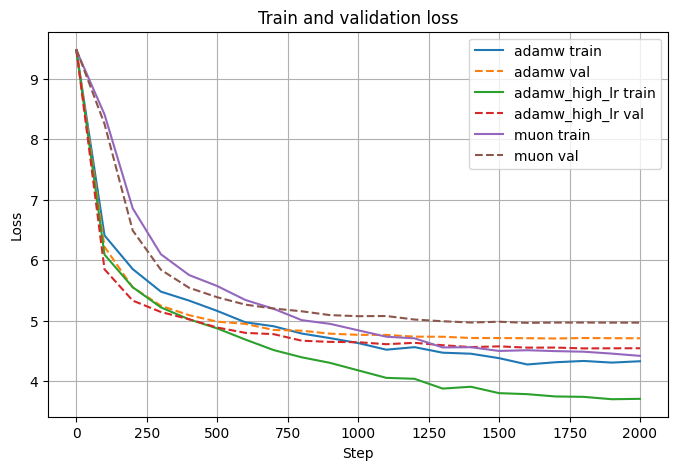

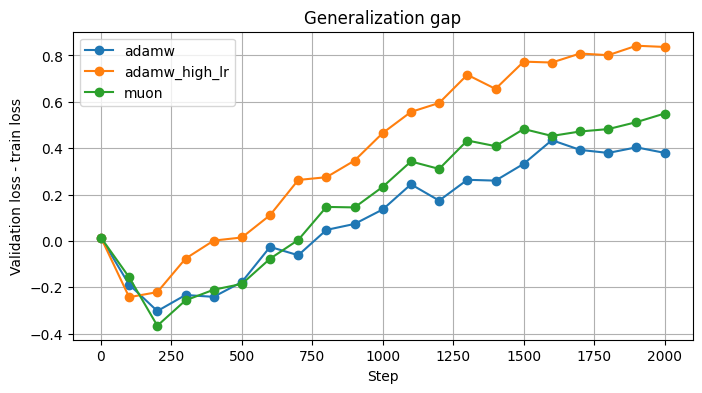

In [15]:
if RUN_TRAINING:
    plt.figure(figsize=(8, 5))
    for opt_name, g in loss_all.groupby("optimizer"):
        plt.plot(g["step"], g["train_loss"], label=f"{opt_name} train")
        plt.plot(g["step"], g["val_loss"], linestyle="--", label=f"{opt_name} val")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title("Train and validation loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 4))
    for opt_name, g in loss_all.groupby("optimizer"):
        gap = g["val_loss"] - g["train_loss"]
        plt.plot(g["step"], gap, marker="o", label=opt_name)
    plt.xlabel("Step")
    plt.ylabel("Validation loss - train loss")
    plt.title("Generalization gap")
    plt.legend()
    plt.grid(True)
    plt.show()

## Subspace drift timeline

Low drift means the subspace stopped moving. High drift means the representation is still reorganizing.

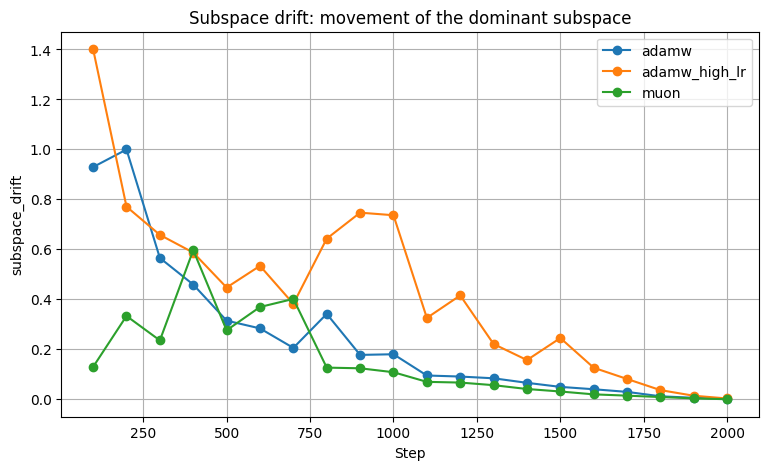

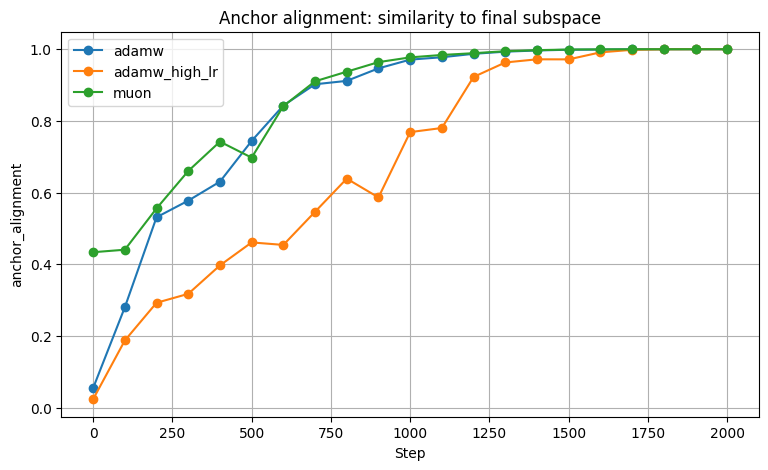

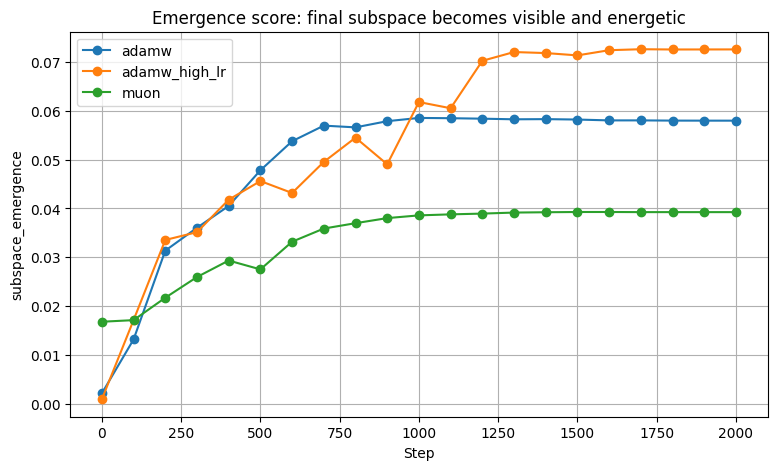

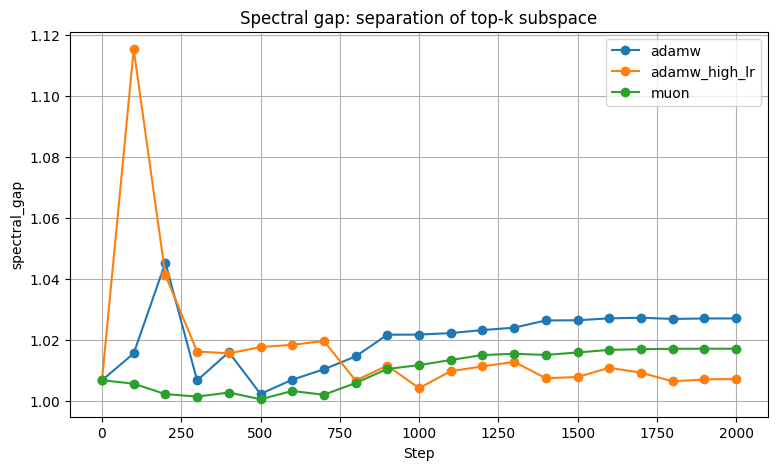

In [16]:
def plot_metric_by_optimizer(df, matrix, k, metric, title=None):
    plt.figure(figsize=(9, 5))
    for opt_name, g in df[(df["matrix"] == matrix) & (df["k"] == k)].groupby("optimizer"):
        plt.plot(g["step"], g[metric], marker="o", label=opt_name)
    plt.xlabel("Step")
    plt.ylabel(metric)
    plt.title(title or f"{metric} | {matrix} | k={k}")
    plt.legend()
    plt.grid(True)
    plt.show()

if RUN_TRAINING:
    example_matrix = CONFIG.target_matrices[0]
    plot_metric_by_optimizer(subspace_df, example_matrix, 4, "subspace_drift", "Subspace drift: movement of the dominant subspace")
    plot_metric_by_optimizer(subspace_df, example_matrix, 4, "anchor_alignment", "Anchor alignment: similarity to final subspace")
    plot_metric_by_optimizer(subspace_df, example_matrix, 4, "subspace_emergence", "Emergence score: final subspace becomes visible and energetic")
    plot_metric_by_optimizer(subspace_df, example_matrix, 4, "spectral_gap", "Spectral gap: separation of top-k subspace")

## Layer heatmap: stabilization time

This plot makes the central question visible:

> Which layers stabilize early, and which keep reorganizing?

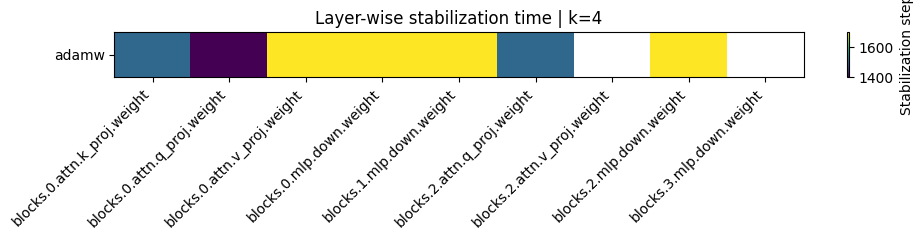

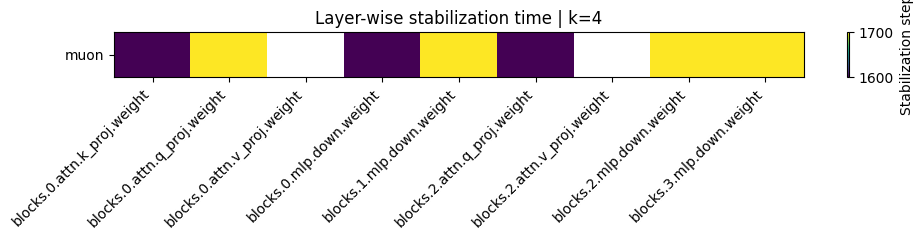

In [17]:
def plot_stabilization_heatmap(stab_df, optimizer, k):
    sub = stab_df[(stab_df["optimizer"] == optimizer) & (stab_df["k"] == k)].copy()
    sub = sub.sort_values("matrix")
    values = sub["stabilization_step"].values.astype(float)[None, :]

    plt.figure(figsize=(10, 2.5))
    im = plt.imshow(values, aspect="auto")
    plt.colorbar(im, label="Stabilization step")
    plt.xticks(range(len(sub)), sub["matrix"], rotation=45, ha="right")
    plt.yticks([0], [optimizer])
    plt.title(f"Layer-wise stabilization time | k={k}")
    plt.tight_layout()
    plt.show()

if RUN_TRAINING:
    for opt_name in ["adamw", "muon"]:
        plot_stabilization_heatmap(stabilization_df, opt_name, 4)

## Subspace phase diagram

Each point is a training state for a matrix at a checkpoint.

The x-axis shows similarity to the final subspace. The y-axis shows energy concentration.

Interpretation:

- Bottom-left: random or unformed state
- Right but low: final direction is present but weak
- Top-right: final dominant subspace has emerged
- Top-left: strong energy, but not yet in the final direction

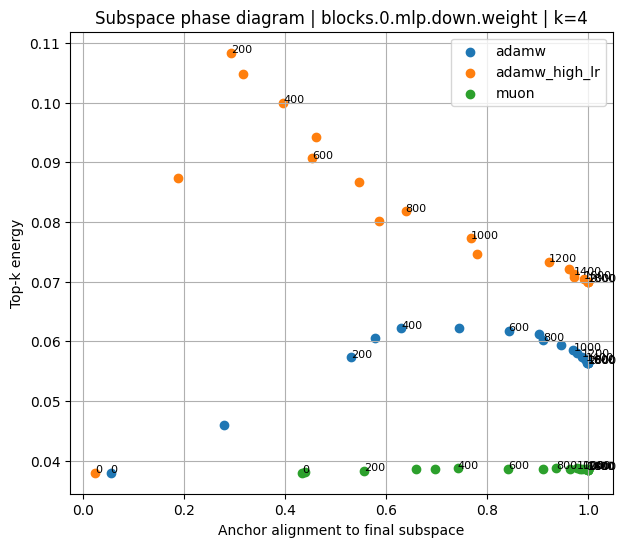

In [18]:
def plot_phase_diagram(df, matrix, k):
    plt.figure(figsize=(7, 6))
    for opt_name, g in df[(df["matrix"] == matrix) & (df["k"] == k)].groupby("optimizer"):
        plt.scatter(g["anchor_alignment"], g["topk_energy"], label=opt_name)
        for _, row in g.iterrows():
            if int(row["step"]) % (CONFIG.diag_interval * 2) == 0:
                plt.text(row["anchor_alignment"], row["topk_energy"], str(int(row["step"])), fontsize=8)
    plt.xlabel("Anchor alignment to final subspace")
    plt.ylabel("Top-k energy")
    plt.title(f"Subspace phase diagram | {matrix} | k={k}")
    plt.legend()
    plt.grid(True)
    plt.show()

if RUN_TRAINING:
    plot_phase_diagram(subspace_df, example_matrix, 4)

## Training-state clustering

We now cluster checkpoint states using subspace features. This is similar in spirit to astronomical anomaly/subset discovery:

- do not inspect every object manually
- represent each training state by useful features
- cluster the states
- interpret the clusters as regimes

A likely interpretation:

1. random / unformed
2. formation
3. consolidation
4. stable refinement

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Clustering: {'method': 'DBSCAN', 'embedding': 'UMAP'}


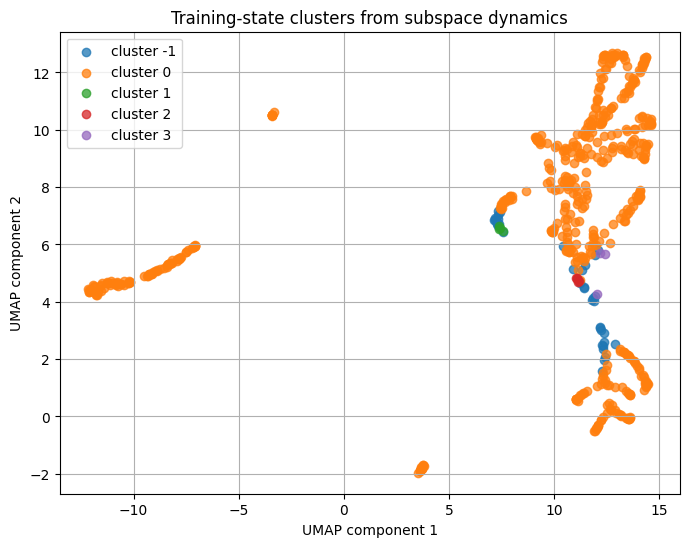

,subspace_drift,anchor_alignment,rolling_alignment,subspace_emergence,topk_energy,stable_rank,spectral_gap,velocity_norm_rel,acceleration_norm_rel
cluster,,,,,,,,,
-1,0.682210,0.534452,0.559725,0.113850,0.167665,20.569187,1.077481,0.284931,0.324536
0,0.191466,0.808369,0.862712,0.089437,0.094585,54.194707,1.030541,0.075296,0.104997
1,0.771832,0.233927,0.917095,0.021188,0.086349,40.688360,1.027350,0.292181,0.329846
2,0.699167,0.283773,0.038682,0.029114,0.097391,32.882086,1.054730,0.295439,0.379770
3,0.333502,0.800099,0.520056,0.140175,0.160702,18.675652,1.052618,0.154408,0.209471


In [19]:
def choose_k_by_silhouette(Xs, k_min=2, k_max=6):
    if not HAS_SKLEARN or len(Xs) < k_min + 1:
        return 1, {}
    scores = {}
    for n_clusters in range(k_min, min(k_max, len(Xs) - 1) + 1):
        labels = KMeans(n_clusters=n_clusters, random_state=42, n_init=10).fit_predict(Xs)
        if len(set(labels)) > 1 and len(set(labels)) < len(Xs):
            scores[n_clusters] = silhouette_score(Xs, labels)
    if not scores:
        return 1, {}
    return max(scores, key=scores.get), scores

def cluster_training_states(df, k=4, method="auto"):
    features = [
        "subspace_drift",
        "anchor_alignment",
        "rolling_alignment",
        "subspace_emergence",
        "topk_energy",
        "stable_rank",
        "spectral_gap",
        "velocity_norm_rel",
        "acceleration_norm_rel",
    ]
    work = df[df["k"] == k].copy()
    for col in features:
        work[col] = work[col].replace([np.inf, -np.inf], np.nan)
        work[col] = work[col].fillna(work[col].median())

    X = work[features].values

    if not HAS_SKLEARN or len(work) < 4:
        work["cluster"] = 0
        work["embed_x"] = work["anchor_alignment"]
        work["embed_y"] = work["subspace_emergence"]
        return work, features, {"method": "fallback", "embedding": "manual"}

    Xs = StandardScaler().fit_transform(X)

    # Prefer DBSCAN for phase/anomaly discovery because it does not require a fixed cluster count.
    if method in ("auto", "dbscan"):
        labels = DBSCAN(eps=1.25, min_samples=4).fit_predict(Xs)
        if len(set(labels)) > 1:
            chosen_method = "DBSCAN"
        else:
            best_k, scores = choose_k_by_silhouette(Xs, 2, 6)
            labels = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit_predict(Xs)
            chosen_method = f"KMeans_silhouette_k={best_k}"
    else:
        best_k, scores = choose_k_by_silhouette(Xs, 2, 6)
        labels = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit_predict(Xs)
        chosen_method = f"KMeans_silhouette_k={best_k}"

    # Nonlinear embedding when available; PCA fallback for portability.
    if HAS_UMAP and len(work) >= 10:
        emb = UMAP(n_components=2, random_state=42, n_neighbors=min(15, len(work)-1), min_dist=0.1).fit_transform(Xs)
        embedding_method = "UMAP"
    else:
        emb = PCA(n_components=2, random_state=42).fit_transform(Xs)
        embedding_method = "PCA"

    work["cluster"] = labels
    work["embed_x"] = emb[:, 0]
    work["embed_y"] = emb[:, 1]
    meta = {"method": chosen_method, "embedding": embedding_method}
    return work, features, meta

if RUN_TRAINING:
    clustered_df, cluster_features, cluster_meta = cluster_training_states(subspace_df, k=4)
    clustered_df.to_csv("subspace_training_state_clusters.csv", index=False)
    print("Clustering:", cluster_meta)

    plt.figure(figsize=(8, 6))
    for cluster_id, g in clustered_df.groupby("cluster"):
        plt.scatter(g["embed_x"], g["embed_y"], label=f"cluster {cluster_id}", alpha=0.75)
    plt.xlabel(f"{cluster_meta['embedding']} component 1")
    plt.ylabel(f"{cluster_meta['embedding']} component 2")
    plt.title("Training-state clusters from subspace dynamics")
    plt.legend()
    plt.grid(True)
    plt.show()

    display(clustered_df.groupby("cluster")[cluster_features].mean())

## Automatic narrative summary

The goal is to translate diagnostics into readable observations.

This is useful for people who do not know the math but still need to understand what happened.

In [20]:
def make_narrative_summary(stab_df, events_df, df, k=4):
    lines = []
    lines.append("Automatic subspace dynamics summary")
    lines.append("=" * 44)
    lines.append("")

    for optimizer in sorted(df["optimizer"].unique()):
        lines.append(f"Optimizer: {optimizer}")
        opt_stab = stab_df[(stab_df["optimizer"] == optimizer) & (stab_df["k"] == k)]
        for _, row in opt_stab.iterrows():
            matrix = row["matrix"]
            stable_step = row["stabilization_step"]
            if np.isfinite(stable_step):
                lines.append(f"- {matrix}: top-{k} subspace stabilized around step {int(stable_step)}.")
            else:
                lines.append(f"- {matrix}: top-{k} subspace did not clearly stabilize within the run.")

        opt_events = events_df[(events_df["optimizer"] == optimizer) & (events_df["k"] == k)]
        births = opt_events[opt_events["event"] == "subspace_birth_or_emergence"]
        if len(births) > 0:
            first_birth = births.sort_values("step").iloc[0]
            lines.append(f"- Earliest detected emergence: {first_birth['matrix']} at step {int(first_birth['step'])}.")
        lines.append("")

    return "\n".join(lines)

if RUN_TRAINING:
    summary_text = make_narrative_summary(stabilization_df, events_df, subspace_df, k=4)
    print(summary_text)
    Path("subspace_dynamics_summary.txt").write_text(summary_text, encoding="utf-8")

Automatic subspace dynamics summary

Optimizer: adamw
- blocks.0.attn.k_proj.weight: top-4 subspace stabilized around step 1500.
- blocks.0.attn.q_proj.weight: top-4 subspace stabilized around step 1400.
- blocks.0.attn.v_proj.weight: top-4 subspace stabilized around step 1700.
- blocks.0.mlp.down.weight: top-4 subspace stabilized around step 1700.
- blocks.1.mlp.down.weight: top-4 subspace stabilized around step 1700.
- blocks.2.attn.q_proj.weight: top-4 subspace stabilized around step 1500.
- blocks.2.attn.v_proj.weight: top-4 subspace did not clearly stabilize within the run.
- blocks.2.mlp.down.weight: top-4 subspace stabilized around step 1700.
- blocks.3.mlp.down.weight: top-4 subspace did not clearly stabilize within the run.

Optimizer: adamw_high_lr
- blocks.0.attn.k_proj.weight: top-4 subspace stabilized around step 1700.
- blocks.0.attn.q_proj.weight: top-4 subspace stabilized around step 1600.
- blocks.0.attn.v_proj.weight: top-4 subspace did not clearly stabilize within th

# How to interpret separated groups

When the cluster plot shows separated groups, they can often be interpreted as training regimes:

## Random / unformed phase

- low anchor alignment
- low emergence
- high drift
- unstable spectral gaps

The matrix has not yet organized into a stable representational geometry.

## Formation phase

- rising anchor alignment
- rising top-k energy
- high but decreasing drift

The final subspace is beginning to appear.

## Consolidation phase

- high emergence
- increasing spectral gap
- falling drift

The dominant subspace is becoming separated and stable.

## Stable refinement phase

- low drift
- high anchor alignment
- small velocity
- small acceleration

The subspace is mostly fixed; training now adjusts magnitudes or smaller residual directions.

This is why subspace tracking is valuable: two optimizers may produce similar loss curves while passing through different geometric regimes.

# Exported files

After a full run, the notebook writes:

```text
loss_curves_emergent_subspaces.csv
raw_spectral_diagnostics_emergent_subspaces.csv
subspace_dynamics_adamw_vs_muon.csv
subspace_stabilization_times.csv
subspace_events_adamw_vs_muon.csv
subspace_training_state_clusters.csv
subspace_dynamics_summary.txt
```

These files are suitable for GitHub artifacts or follow-up analysis.

Additional ICA outputs:

```text
ica_spatial_components.csv
ica_component_counts.csv
ica_component_tracks.csv
ica_component_track_summary.csv
ica_temporal_modes.csv
```


# Suggested repository name

Recommended repository name:

```text
emergent-subspaces
```

Alternative names:

```text
subspace-observatory
training-subspace-dynamics
subspace-ecology
representation-subspace-tracker
```

## Muon literature comparison and result interpretation

This final section adds a research interpretation layer. It does **not** change the Tiny Qwen model, vocabulary, training loop, optimizer implementation, subspace diagnostics, or ICA diagnostics.

The main empirical pattern is:

> Muon does not necessarily win on validation loss in this small Tiny-Qwen / WikiText-2 / word-tokenized setting, but it induces a different geometry: higher stable rank, more stabilized top-k subspaces, fewer ICA components, and a more coherent diagnostic trajectory.

Conservative interpretation:

- Muon appears to preserve broader spectral support.
- Muon appears to consolidate activation components.
- Muon’s geometric organization is not automatically equivalent to better validation loss.
- Destabilization spikes may indicate subspace reorganization events, but this requires explicit spike-level analysis.

Literature-facing phrasing:

> In this small-scale Tiny-Qwen experiment, Muon did not improve validation loss relative to AdamW baselines. However, it induced a distinct geometric regime: higher stable rank in FFN down-projection matrices, fewer ICA activation components, more top-k subspace stabilization events, and a more coherent diagnostic trajectory. These results suggest that orthogonalized matrix updates impose an implicit spectral-geometric bias that is not captured by loss curves alone.

In [ ]:
# ============================================================
# Load exported diagnostics for Muon literature comparison
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def load_csv_if_exists(path):
    path = Path(path)
    if path.exists():
        return pd.read_csv(path)
    print(f"Missing: {path.name}")
    return pd.DataFrame()

loss_csv = load_csv_if_exists("loss_curves_emergent_subspaces.csv")
subspace_csv = load_csv_if_exists("subspace_dynamics_adamw_vs_muon.csv")
stabilization_csv = load_csv_if_exists("subspace_stabilization_times.csv")
events_csv = load_csv_if_exists("subspace_events_adamw_vs_muon.csv")
clusters_csv = load_csv_if_exists("subspace_training_state_clusters.csv")
ica_counts_csv = load_csv_if_exists("ica_component_counts.csv")
ica_track_summary_csv = load_csv_if_exists("ica_component_track_summary.csv")

loaded_rows = []
for name, df in [
    ("loss", loss_csv),
    ("subspace", subspace_csv),
    ("stabilization", stabilization_csv),
    ("events", events_csv),
    ("clusters", clusters_csv),
    ("ica_counts", ica_counts_csv),
    ("ica_track_summary", ica_track_summary_csv),
]:
    loaded_rows.append({"table": name, "rows": len(df), "available": not df.empty})
loaded_summary = pd.DataFrame(loaded_rows)
display(loaded_summary)

### Example-data fallback

If you open this notebook before running training, this section uses a small example table reflecting the qualitative pattern from the current experiment. Once the exported CSV files exist, the real data are used automatically.

In [ ]:
example_summary = pd.DataFrame([
    {"optimizer": "adamw", "final_val_loss": 4.98, "stable_rank_example": 50, "final_ica_components": 39, "stabilized_top4_count": 6, "mean_track_lifetime": 4.5},
    {"optimizer": "adamw_high_lr", "final_val_loss": 4.64, "stable_rank_example": 27, "final_ica_components": 46, "stabilized_top4_count": 1, "mean_track_lifetime": 3.4},
    {"optimizer": "muon", "final_val_loss": 5.11, "stable_rank_example": 103, "final_ica_components": 35, "stabilized_top4_count": 8, "mean_track_lifetime": 4.8},
])
display(example_summary)

## Loss versus geometry

The first sanity check is to separate two questions:

1. Which optimizer gets the best validation loss?
2. Which optimizer creates the most distinctive matrix / subspace / component geometry?

These are not the same question. The current run suggests that loss optimum and geometric equilibrium can diverge.

In [ ]:
def summarize_loss(loss_df):
    if loss_df.empty:
        return example_summary[["optimizer", "final_val_loss"]].copy()
    rows = []
    for opt, g in loss_df.sort_values("step").groupby("optimizer"):
        final = g.iloc[-1]
        best = g.loc[g["val_loss"].idxmin()]
        rows.append({
            "optimizer": opt,
            "final_train_loss": float(final["train_loss"]),
            "final_val_loss": float(final["val_loss"]),
            "final_gap": float(final["val_loss"] - final["train_loss"]),
            "best_val_loss": float(best["val_loss"]),
            "step_at_best_val": int(best["step"]),
        })
    return pd.DataFrame(rows).sort_values("best_val_loss")

loss_summary = summarize_loss(loss_csv)
display(loss_summary)

plt.figure(figsize=(8, 4))
ycol = "best_val_loss" if "best_val_loss" in loss_summary.columns else "final_val_loss"
plt.bar(loss_summary["optimizer"], loss_summary[ycol])
plt.ylabel(ycol)
plt.title("Validation loss by optimizer")
plt.grid(True, axis="y")
plt.show()

## Stable rank as spectral diversity

Stable rank is:

\[
\operatorname{srank}(W)=\frac{\|W\|_F^2}{\|W\|_2^2}
\]

Low stable rank means matrix energy is concentrated into a few singular directions. High stable rank means energy is distributed across many directions.

Muon-style orthogonalized updates are expected to preserve or promote spectral diversity. Therefore, a higher Muon stable rank is consistent with the idea that Muon induces a different matrix geometry than AdamW.

In [ ]:
def summarize_stable_rank(subspace_df, matrix_name="blocks.3.mlp.down.weight", k=4):
    if subspace_df.empty:
        return example_summary[["optimizer", "stable_rank_example"]].rename(columns={"stable_rank_example": "final_stable_rank"})
    sub = subspace_df[(subspace_df["matrix"] == matrix_name) & (subspace_df["k"] == k)].copy()
    if sub.empty:
        sub = subspace_df[subspace_df["k"] == k].copy()
    rows = []
    for opt, g in sub.sort_values("step").groupby("optimizer"):
        final = g.iloc[-1]
        rows.append({
            "optimizer": opt,
            "matrix": final.get("matrix", matrix_name),
            "final_step": int(final["step"]),
            "final_stable_rank": float(final["stable_rank"]),
            "final_topk_energy": float(final["topk_energy"]),
            "final_spectral_gap": float(final["spectral_gap"]),
        })
    return pd.DataFrame(rows).sort_values("final_stable_rank", ascending=False)

stable_rank_summary = summarize_stable_rank(subspace_csv)
display(stable_rank_summary)

plt.figure(figsize=(8, 4))
plt.bar(stable_rank_summary["optimizer"], stable_rank_summary["final_stable_rank"])
plt.ylabel("Final stable rank")
plt.title("Spectral diversity: stable rank")
plt.grid(True, axis="y")
plt.show()

## Top-k subspace stabilization

A top-\(k\) subspace is marked as stabilized when Grassmann drift stays below threshold for a sustained window.

If Muon stabilizes more top-4 subspaces while having worse validation loss, the conclusion is not “Muon is better.” The conclusion is:

> Muon induces a more coherent subspace organization under this diagnostic, but that organization is not sufficient for better validation loss in this setup.

In [ ]:
def summarize_stabilization(stab_df, k=4):
    if stab_df.empty:
        return example_summary[["optimizer", "stabilized_top4_count"]].rename(columns={"stabilized_top4_count": "stabilized_count"})
    sub = stab_df[stab_df["k"] == k].copy()
    rows = []
    for opt, g in sub.groupby("optimizer"):
        stabilized = g["stabilization_step"].notna()
        rows.append({
            "optimizer": opt,
            "tracked_matrices": int(len(g)),
            "stabilized_count": int(stabilized.sum()),
            "stabilized_fraction": float(stabilized.mean()),
            "median_stabilization_step": float(g.loc[stabilized, "stabilization_step"].median()) if stabilized.any() else np.nan,
        })
    return pd.DataFrame(rows).sort_values("stabilized_count", ascending=False)

stab_summary = summarize_stabilization(stabilization_csv, k=4)
display(stab_summary)

plt.figure(figsize=(8, 4))
plt.bar(stab_summary["optimizer"], stab_summary["stabilized_count"])
plt.ylabel("Stabilized top-4 subspaces")
plt.title("Top-4 subspace stabilization count")
plt.grid(True, axis="y")
plt.show()

## Event types: emergence, spectral separation, destabilization

Event types are useful because they distinguish different training mechanisms:

- **subspace_birth_or_emergence**: a new/final-like subspace becomes visible
- **spectral_separation**: the top subspace separates from the rest of the spectrum
- **destabilization_spike**: a previously stable subspace suddenly moves

A Muon-heavy pattern of destabilization spikes can be interpreted as possible subspace reorganization. To support this strongly, correlate each spike with stable-rank changes, top-k energy changes, loss changes, and later re-stabilization.

In [ ]:
def summarize_events(events_df):
    if events_df.empty:
        return pd.DataFrame({
            "optimizer": ["adamw", "adamw_high_lr", "muon"],
            "destabilization_spike": [0, 0, 8],
            "spectral_separation": [23, 0, 0],
            "subspace_birth_or_emergence": [3, 0, 0],
        })
    return (
        events_df.groupby(["optimizer", "event"])
        .size()
        .reset_index(name="count")
        .pivot(index="optimizer", columns="event", values="count")
        .fillna(0)
        .reset_index()
    )

event_summary = summarize_events(events_csv)
display(event_summary)

plot_df = event_summary.set_index("optimizer")
plt.figure(figsize=(10, 5))
bottom = np.zeros(len(plot_df))
for col in plot_df.columns:
    vals = plot_df[col].values
    plt.bar(plot_df.index, vals, bottom=bottom, label=col)
    bottom += vals
plt.ylabel("Event count")
plt.title("Subspace event types by optimizer")
plt.legend()
plt.grid(True, axis="y")
plt.show()

## ICA compactness

The ICA component count estimates how many independent FFN component maps are useful at a checkpoint.

A useful reading is:

- more ICA components: more fragmented or more diverse independent activation factors
- fewer ICA components: more compact component organization
- fewer ICA components + higher stable rank: fewer functional components distributed across broader matrix subspaces

This last combination is especially interesting for Muon.

In [ ]:
def summarize_ica_counts(count_df):
    if count_df.empty:
        return example_summary[["optimizer", "final_ica_components"]].rename(columns={"final_ica_components": "final_n_ica"})
    rows = []
    for opt, g in count_df.sort_values("step").groupby("optimizer"):
        first = g.iloc[0]
        final = g.iloc[-1]
        rows.append({
            "optimizer": opt,
            "start_n_ica": int(first["n_ica"]),
            "final_n_ica": int(final["n_ica"]),
            "delta_n_ica": int(final["n_ica"] - first["n_ica"]),
            "final_participation_ratio": float(final["participation_ratio"]),
        })
    return pd.DataFrame(rows).sort_values("final_n_ica")

ica_count_summary = summarize_ica_counts(ica_counts_csv)
display(ica_count_summary)

if not ica_counts_csv.empty:
    plt.figure(figsize=(9, 5))
    for opt, g in ica_counts_csv.groupby("optimizer"):
        plt.plot(g["step"], g["n_ica"], marker="o", label=opt)
    plt.xlabel("Training step")
    plt.ylabel("Estimated ICA components")
    plt.title("ICA component count over training")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    plt.figure(figsize=(8, 4))
    plt.bar(ica_count_summary["optimizer"], ica_count_summary["final_n_ica"])
    plt.ylabel("Final estimated ICA components")
    plt.title("Example ICA component compactness")
    plt.grid(True, axis="y")
    plt.show()

## Conservative interpretation table

This table is the recommended paper-level framing. It avoids claiming that Muon is universally better and instead states that it has a distinct implicit geometric bias.

In [ ]:
interpretation_table = pd.DataFrame([
    {
        "observation": "Muon has higher stable rank",
        "interpretation": "Muon preserves more spectral directions in matrix parameters.",
        "confidence": "high",
        "caution": "Needs multi-seed and larger-model confirmation."
    },
    {
        "observation": "Muon has fewer final ICA components",
        "interpretation": "Activation structure may be more compact, not necessarily lower-rank.",
        "confidence": "medium",
        "caution": "ICA can be sensitive to whitening, convergence, and component matching."
    },
    {
        "observation": "Muon stabilizes more top-4 subspaces",
        "interpretation": "Muon induces a coherent subspace organization.",
        "confidence": "medium-high",
        "caution": "Threshold and rolling-anchor lag sensitivity are needed."
    },
    {
        "observation": "Muon has worse validation loss here",
        "interpretation": "Geometric regularity is not equivalent to better language modeling.",
        "confidence": "high",
        "caution": "Muon LR/update scale may be suboptimal for this small word-tokenized setup."
    },
    {
        "observation": "Destabilization spikes appear under Muon",
        "interpretation": "Possible subspace reorganization events.",
        "confidence": "medium",
        "caution": "Correlate spikes with stable-rank, loss, and post-spike re-stabilization."
    },
])
display(interpretation_table)

## Recommended next experiments

1. **Multi-seed replication:** at least 3 seeds, preferably 5.
2. **Muon LR sweep:** \(3e^{-4}, 5e^{-4}, 1e^{-3}\).
3. **Update-scale diagnostics:** compare RMS update norms across optimizers.
4. **Rolling-anchor lag sensitivity:** compare 100, 200, 300, 500.
5. **Spike analysis:** stable-rank/top-k-energy/loss before and after each Muon destabilization spike.
6. **Tokenizer robustness:** report train/validation `<unk>` ratio in every final summary.

In [ ]:
def analyze_destabilization_spikes(events_df, subspace_df, optimizer="muon", window_steps=200):
    if events_df.empty or subspace_df.empty:
        print("Need events_df and subspace_df to analyze spikes.")
        return pd.DataFrame()

    spikes = events_df[(events_df["optimizer"] == optimizer) & (events_df["event"] == "destabilization_spike")].copy()
    rows = []

    for _, ev in spikes.iterrows():
        matrix = ev["matrix"]
        k = ev["k"]
        step = ev["step"]

        g = subspace_df[
            (subspace_df["optimizer"] == optimizer) &
            (subspace_df["matrix"] == matrix) &
            (subspace_df["k"] == k)
        ].sort_values("step")

        before = g[g["step"] <= step - window_steps].tail(1)
        at = g[g["step"] <= step].tail(1)
        after = g[g["step"] >= step + window_steps].head(1)

        if before.empty or at.empty or after.empty:
            continue

        b, a, f = before.iloc[0], at.iloc[0], after.iloc[0]
        rows.append({
            "optimizer": optimizer,
            "matrix": matrix,
            "k": k,
            "spike_step": int(step),
            "event_value": float(ev["value"]),
            "stable_rank_before": float(b["stable_rank"]),
            "stable_rank_at": float(a["stable_rank"]),
            "stable_rank_after": float(f["stable_rank"]),
            "delta_stable_rank_after": float(f["stable_rank"] - b["stable_rank"]),
            "topk_energy_before": float(b["topk_energy"]),
            "topk_energy_after": float(f["topk_energy"]),
            "delta_topk_energy_after": float(f["topk_energy"] - b["topk_energy"]),
        })

    return pd.DataFrame(rows)

spike_analysis = analyze_destabilization_spikes(events_csv, subspace_csv, optimizer="muon", window_steps=200)
display(spike_analysis)
if not spike_analysis.empty:
    spike_analysis.to_csv("muon_destabilization_spike_analysis.csv", index=False)